# 02 — Cupid: sampling assignments and compressing them

Two Markov chains. The first walks over **matchings** between BGCs and metabolites, scored so that
large matchings with few conflicts are favoured. The second walks over **clusterings** of the nodes,
scored by how many bits it takes to describe the sampled matchings through the resulting summary
graph.

The score has three constants and all of them are fixed in advance rather than tuned, so no
information the baseline lacks enters the model. Nothing is filtered either: every draw the chain
produces is used, both for the marginals and for the summary graph, so what we report are the
marginals of the distribution we actually sampled from.

The notebook reads only the masked graph. The ground truth is loaded to score the result and never
touches the sampler or the clustering.

## The score

A matching is scored by `f(A) = exp(ALPHA*|A| - BETA*|C^M(A)| - MU*|C^B(A)| + GAMMA*s(A))`, subject
to the hard constraint that each BGC and each metabolite is used at most once. Here `|A|` counts
explained metabolites, `C^M(A)` collects strains that produce a metabolite while lacking the BGC
credited with it, `C^B(A)` collects strains that carry the BGC and never produce the metabolite, and
`s` carries optional prior knowledge.

The two conflict sets are not symmetric in meaning. An element of `C^M` is impossible, so `BETA` is
large. An element of `C^B` is merely uninformative, since a cluster can be silent, so `MU` is small.
Both belong to exactly one pair, so each is a sum of per-pair constants, every pair has a fixed
weight, and each Metropolis step is a table lookup.

In [1]:
try:                       # inline figures in Jupyter; a plain script has no IPython,
    get_ipython().run_line_magic("matplotlib", "inline")   # so fall back to a
except NameError:                                          # headless backend
    import matplotlib
    matplotlib.use("Agg")
import json
import time
import math
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="white", context="talk", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "figure.facecolor": "white", "savefig.facecolor": "white",
    "axes.grid": False, "xtick.bottom": False, "ytick.left": False,
    "legend.frameon": False,
})

# ----------------------------------------------------------------- configuration
SEED = 0                 # every random draw below derives from this

ALPHA = 20.0             # bonus per explained metabolite; larger concentrates the
                         # chain on large matchings, smaller admits suboptimal ones.
                         # It has to be large enough to reach maximum matchings at all:
                         # the number of matchings falls steeply near the maximum, so
                         # ALPHA must outweigh the entropy given up by explaining one
                         # more metabolite. Below about 4 the chain never reaches the
                         # ground-truth size of 78 and the posterior settles a dozen
                         # metabolites short of it.
BETA = 10.0              # penalty per element of C^M, a strain producing without carrying
MU = 1.0                 # NEW: penalty per element of C^B, a strain carrying without
                         # producing. The published score omits this direction, so every
                         # pair that merely avoids a conflict looks equally good and a
                         # BGC present in nearly every strain becomes a candidate for
                         # every metabolite.
                         #
                         # All three are fixed, not tuned. They are round numbers chosen
                         # a priori, not fitted to this dataset and not derived from the
                         # masking parameters of notebook 01, so nothing the baseline
                         # cannot see enters here. The results are insensitive to them:
                         # average precision stays between 0.976 and 0.987 across
                         # ALPHA in 10 to 30, BETA in 5 to 10 and MU in 0 to 1.2, and it
                         # is flat for any ALPHA at or above 20.
GAMMA = 0.0              # weight of the biological prior in the main chain; zero for
                         # every result outside Part 9
GAMMA_PRIOR = 3.0        # the weight Part 9 actually reports. s(A) is a discordance
                         # fraction in [-1, 0], so this is the number of nats an
                         # assignment is charged when it breaks the size rule every
                         # time. Raising it eventually overrides the data, since the
                         # size signal is weak (Kendall tau about 0.32 on true pairs)

N_SAMPLES = 1_000        # matchings drawn from the first chain. Every one of them is
                         # used, for the marginals and for the summary graph alike.
                         # There is no score filter, so what we report are the marginals
                         # of the distribution we actually sampled from rather than of a
                         # truncated one
BURN_IN = 500_000        # steps discarded before the first draw. Adding MU and raising
                         # ALPHA to match drops the acceptance rate below one percent,
                         # and the chain then needs far longer to find the optimal face.
                         # At BURN_IN 200_000 with THIN 50 it stalls in a basin with two
                         # to six conflicts and never reaches an optimal assignment.
THIN = 200               # steps between draws; larger decorrelates, at more cost

N_CLUSTER_STEPS = 10_000 # steps of the clustering chain
TEMP_START, TEMP_END = 4.0, 0.05   # the clustering chain is an optimizer, so it is
                                   # cooled rather than run at a fixed temperature
SMOOTH = 0.5             # additive smoothing of the block-count histograms, so an
                         # unseen count costs many bits rather than infinitely many
LAMBDA_MODEL = 1.0       # weight on the cost of describing the summary graph itself.
                         # At 0 the model is free and singletons always win, since
                         # merging pays for placements without saving anything. At 1
                         # this is proper two-part MDL. Raising it merges more freely.

N_EDITS = 20             # largest number of random edits in the robustness check
N_EDIT_SEEDS = 20        # repetitions per edit count
N_TIE_RUNS = 100         # random tie-break repetitions for the ranking
K_PLOT_MAX = 500         # right edge of the recall@k plot; recall has saturated well
                         # before this, so a larger value only adds empty axis

_MUTED = sns.color_palette("muted")
COLORS = {"microbe": _MUTED[0], "family": _MUTED[3], "molecule": _MUTED[1],
          "cupid": _MUTED[2], "baseline": _MUTED[4], "prior": _MUTED[0]}
WRITTEN, FACTS = [], []

REPO_ROOT = Path("..").resolve()
DATASET = "dataset1_streptomyces"     # subfolder of data/ written by notebook 01
DATA_DIR = REPO_ROOT / "data" / DATASET
OUT_DIR = REPO_ROOT / "output" / "02_streptomyces_cupid"
OUT_DIR.mkdir(parents=True, exist_ok=True)
BASE_RANKS = REPO_ROOT / "output" / "03_streptomyces_baseline" / "part6_ranks.csv"
BASE_CURVE = REPO_ROOT / "output" / "03_streptomyces_baseline" / "part6_recall_at_k.csv"

TRUTH_JSON = DATA_DIR / "ground_truth_metabologenomics_graph.json"
MASKED_JSON = DATA_DIR / "masked_metabologenomics_graph.json"
FEATURES_CSV = DATA_DIR / "node_features.csv"
for p in (TRUTH_JSON, MASKED_JSON):
    if not p.exists():
        raise FileNotFoundError(f"{p.name} missing - run notebook 01 first.")


def save_fig(fig, name, data=None):
    for ext in ("jpg", "pdf"):
        p_ = OUT_DIR / f"{name}.{ext}"
        fig.savefig(p_)
        WRITTEN.append(p_)
    if data is not None:
        p_ = OUT_DIR / f"{name}.csv"
        data.to_csv(p_, index=False)
        WRITTEN.append(p_)


def note(section, key, value):
    FACTS.append((section, key, value))
    return value


print(f"input : {DATA_DIR.relative_to(REPO_ROOT)}/")
print(f"output: {OUT_DIR.relative_to(REPO_ROOT)}/")

input : data/dataset1_streptomyces/
output: output/02_streptomyces_cupid/


## 1. Load the data and precompute the pair weights

`C[i,j]` counts the strains that produce metabolite `j` without carrying BGC `i`. It depends only on
the data, so it is computed once and every acceptance ratio afterwards is a lookup into it.

In [2]:
def load_graph(path):
    data = json.loads(path.read_text())
    try:
        return nx.node_link_graph(data, edges="links")
    except TypeError:
        return nx.node_link_graph(data)


G_masked, G_truth = load_graph(MASKED_JSON), load_graph(TRUTH_JSON)

strains = sorted(n for n, d in G_masked.nodes(data=True) if d["ntype"] == "microbe")
bgcs = sorted(n for n, d in G_masked.nodes(data=True) if d["ntype"] == "family")
mols = sorted(n for n, d in G_masked.nodes(data=True) if d["ntype"] == "molecule")
si = {s: k for k, s in enumerate(strains)}
bi = {b: k for k, b in enumerate(bgcs)}
mi = {m: k for k, m in enumerate(mols)}
N_s, N_b, N_m = len(strains), len(bgcs), len(mols)

B = np.zeros((N_s, N_b), dtype=np.int8)
M = np.zeros((N_s, N_m), dtype=np.int8)
for u, v, d in G_masked.edges(data=True):
    a, b = (u, v) if G_masked.nodes[u]["ntype"] == "microbe" else (v, u)
    if d["etype"] == "carries":
        B[si[a], bi[b]] = 1
    else:
        M[si[a], mi[b]] = 1

# ground truth, used for evaluation only
true_pairs = set()
for u, v, d in G_truth.edges(data=True):
    if d["etype"] != "produces":
        continue
    f, m = (u, v) if G_truth.nodes[u]["ntype"] == "family" else (v, u)
    true_pairs.add((bi[f], mi[m]))

C = ((1 - B).astype(np.int32).T @ M.astype(np.int32))     # N_b x N_m conflicts
# NEW: N10[i, j] counts strains carrying BGC i that never produce metabolite j, so
# summing it over a matching gives |C^B(A)| exactly as |C(A)| gives |C^M(A)|. The
# published score omits this direction entirely.
N10 = B.sum(0)[:, None].astype(np.int32) - (B.astype(np.int32).T @ M.astype(np.int32))
WEIGHT = ALPHA - BETA * C - MU * N10                       # fixed weight per pair

note("SETUP", "strains (N_s)", N_s)
note("SETUP", "BGCs (N_b)", N_b)
note("SETUP", "metabolites (N_m)", N_m)
note("SETUP", "true links", len(true_pairs))
for k, v in (("alpha", ALPHA), ("beta", BETA),
             ("gamma", GAMMA), ("seed", SEED),
             ("mu", MU), ("samples drawn", N_SAMPLES),
             ("samples kept", "all, no filter"),
             ("burn-in", BURN_IN), ("thinning", THIN),
             ("clustering steps", N_CLUSTER_STEPS)):
    note("CONFIGURATION", k, v)

print(f"strains {N_s} | BGCs {N_b} | metabolites {N_m} | true links {len(true_pairs)}")
print(f"conflict-free pairs: {(C == 0).sum():,} of {N_b * N_m:,}")
print(f"pair weight: max {WEIGHT.max():.1f}, median {np.median(WEIGHT):.1f}")

strains 62 | BGCs 96 | metabolites 78 | true links 78
conflict-free pairs: 725 of 7,488
pair weight: max 20.0, median -12.0


## 2. The matching chain

One move type. Pick a pair uniformly at random and, depending on the current state, propose to
remove it, add it, or exchange it for the edge blocking it. The proposal is symmetric, since the
reverse of every move is proposed by picking the same pair, so the acceptance is the plain
Metropolis ratio with no correction.

In [3]:
def run_matching_chain(seed, n_samples, weight=None, burn_in=BURN_IN, thin=THIN):
    # resolved here rather than as a default, since Part 2b rebinds WEIGHT after
    # tuning and a default argument would still hold the pre-tuning table
    weight = WEIGHT if weight is None else weight
    rng = np.random.default_rng(seed)
    mol_of = np.full(N_b, -1, dtype=np.int32)   # BGC -> metabolite, -1 unmatched
    bgc_of = np.full(N_m, -1, dtype=np.int32)   # metabolite -> BGC

    total = burn_in + n_samples * thin
    ii = rng.integers(0, N_b, size=total)
    jj = rng.integers(0, N_m, size=total)
    uu = np.log(rng.random(total))              # compare against delta directly

    out = np.empty((n_samples, N_m), dtype=np.int32)
    scores = np.empty(n_samples)
    score, accepted, k = 0.0, 0, 0
    for step in range(total):
        i, j = int(ii[step]), int(jj[step])
        cur_j, cur_i = int(mol_of[i]), int(bgc_of[j])
        evicted = -1
        if cur_j == j:                                   # remove the pair
            delta, kind = -weight[i, j], 0
        elif cur_j == -1 and cur_i == -1:                # add it
            delta, kind = weight[i, j], 1
        elif cur_j != -1 and cur_i == -1:                # re-aim a busy BGC
            delta, kind, evicted = weight[i, j] - weight[i, cur_j], 2, cur_j
        elif cur_j == -1 and cur_i != -1:                # steal a taken metabolite
            delta, kind, evicted = weight[i, j] - weight[cur_i, j], 3, cur_i
        else:                                            # both busy elsewhere
            kind = -1
        if kind >= 0 and (delta >= 0 or uu[step] < delta):
            accepted += 1
            if kind == 0:
                mol_of[i] = -1
                bgc_of[j] = -1
            else:
                if kind == 2:
                    bgc_of[evicted] = -1
                elif kind == 3:
                    mol_of[evicted] = -1
                mol_of[i] = j
                bgc_of[j] = i
            score += delta
        if step >= burn_in and (step - burn_in) % thin == 0 and k < n_samples:
            out[k] = bgc_of
            scores[k] = score
            k += 1
    return out, scores, accepted / total

## 2b. The parameters, and the largest possible assignment

`ALPHA`, `BETA` and `MU` are fixed, not tuned. They are round numbers chosen in advance rather than
fitted to this dataset, and in particular `MU` is not derived from the masking rate of notebook 01,
so nothing the baseline cannot see enters the model. The results barely move across a wide range of
all three.

The largest attainable assignment is not left to the sampler. On the graph of conflict-free pairs it
is a maximum bipartite matching, which Hopcroft--Karp returns exactly, so we know before sampling
what an optimal assignment looks like and can report what share of the posterior reaches it.

In [4]:
# exact maximum matching over the conflict-free pairs, by Hopcroft-Karp
G_free = nx.Graph()
G_free.add_nodes_from([("b", i) for i in range(N_b)], bipartite=0)
G_free.add_nodes_from([("m", j) for j in range(N_m)], bipartite=1)
zi, zj = np.nonzero(C == 0)
G_free.add_edges_from([(("b", int(i)), ("m", int(j))) for i, j in zip(zi, zj)])
MAX_SIZE = len(nx.bipartite.maximum_matching(
    G_free, top_nodes=[("b", i) for i in range(N_b)])) // 2
note("SETUP", "conflict-free pairs", int((C == 0).sum()))
note("SETUP", "maximum conflict-free matching size (exact)", MAX_SIZE)
print(f"maximum conflict-free matching size: {MAX_SIZE} "
      f"(over {(C == 0).sum():,} conflict-free pairs)")
print(f"parameters, all fixed: alpha {ALPHA}, beta {BETA}, mu {MU}")

samples, scores, acc_rate = run_matching_chain(SEED, N_SAMPLES)
note("SAMPLER", "acceptance rate", f"{acc_rate:.1%}")
print(f"acceptance rate {acc_rate:.1%}")
print(f"score: first {scores[0]:.1f}, last {scores[-1]:.1f}, best {scores.max():.1f}")

maximum conflict-free matching size: 78 (over 725 conflict-free pairs)
parameters, all fixed: alpha 20.0, beta 10.0, mu 1.0


acceptance rate 0.7%
score: first 1379.0, last 1383.0, best 1383.0


## 3. The sample set

Keep the highest-scoring draws. A second chain from a different seed provides the convergence
check: if the first had not converged, the two score distributions would disagree.

seed 0 mean score 1379.38 | seed 1 1369.42 | difference 9.96
all 1,000 draws: |A| 77-78, conflicts 0-0
optimal draws: 889 (88.9%)


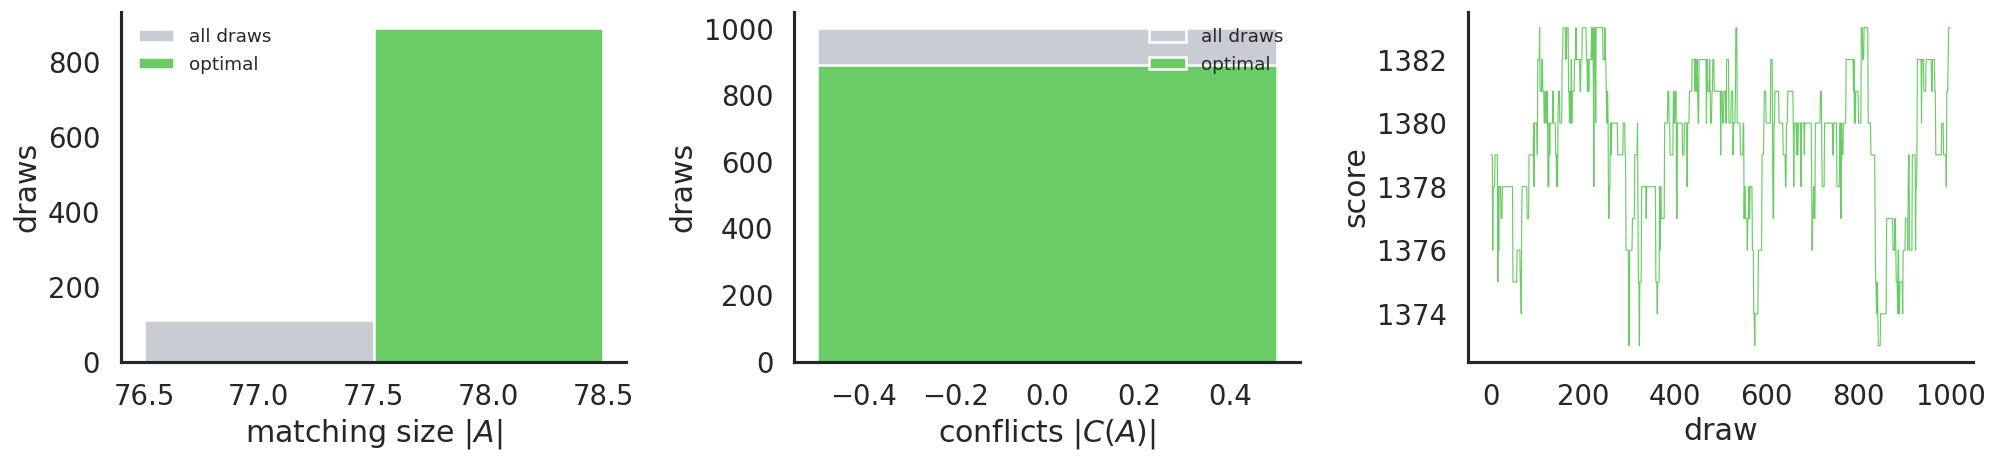

In [5]:
rows = np.arange(N_m)
sizes = (samples >= 0).sum(1)
conflicts = np.array([C[samples[t][samples[t] >= 0], rows[samples[t] >= 0]].sum()
                      for t in range(N_SAMPLES)])

# NEW: no score filter. Earlier versions kept the N_KEEP highest-scoring draws, so the
# reported marginals were those of a truncated distribution rather than of the one we
# sampled. Every draw counts now, and the same set feeds the summary graph of Part 5.
order = np.arange(N_SAMPLES)
kept = samples                       # every draw, for the marginals and the summary graph
T = N_SAMPLES
note("SAMPLER", "assignments used, no filter", T)

_, scores2, _ = run_matching_chain(SEED + 1, 2_000)
agree = abs(scores.mean() - scores2.mean())
note("SAMPLER", "mean score, seed 0", f"{scores.mean():.2f}")
note("SAMPLER", "mean score, seed 1", f"{scores2.mean():.2f}")
is_opt = (conflicts == 0) & (sizes == MAX_SIZE)
note("SAMPLER", "matching size over all draws", f"{sizes.min()}-{sizes.max()}")
note("SAMPLER", "conflicts over all draws", f"{conflicts.min()}-{conflicts.max()}")
note("SAMPLER", "share of draws that are optimal", f"{is_opt.mean():.1%}")
print(f"seed 0 mean score {scores.mean():.2f} | seed 1 {scores2.mean():.2f} "
      f"| difference {agree:.2f}")
print(f"all {N_SAMPLES:,} draws: |A| {sizes.min()}-{sizes.max()}, "
      f"conflicts {conflicts.min()}-{conflicts.max()}")
print(f"optimal draws: {is_opt.sum():,} ({is_opt.mean():.1%})")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
for ax, vals, lab in ((axes[0], (sizes, sizes[is_opt]), "matching size $|A|$"),
                      (axes[1], (conflicts, conflicts[is_opt]), "conflicts $|C(A)|$")):
    allv, subv = vals
    bins = np.arange(allv.min(), allv.max() + 2) - 0.5
    ax.hist(allv, bins=bins, color="#c9ccd3", label="all draws")
    ax.hist(subv, bins=bins, color=COLORS["cupid"], label="optimal")
    ax.set_xlabel(lab)
    ax.set_ylabel("draws")
    ax.legend(fontsize=11)
axes[2].plot(scores, lw=0.7, color=COLORS["cupid"])
axes[2].set_xlabel("draw")
axes[2].set_ylabel("score")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
save_fig(fig, "part3_sample_distributions",
         pd.DataFrame({"draw": np.arange(N_SAMPLES), "size": sizes,
                       "conflicts": conflicts, "score": scores,
                       "retained": np.isin(np.arange(N_SAMPLES), order)}))
plt.show()

### The joint distribution

The two marginals above hide the trade the score actually makes. `f(A)` pays `ALPHA` for each
explained metabolite and charges `BETA` for each conflict, so the interesting question is whether
the chain ever buys a larger matching by accepting a conflict. The heatmap answers it directly, one
cell per attainable `(|A|, |C(A)|)` pair, coloured by the fraction of draws landing there.

The colour scale is logarithmic, since the mass is concentrated in a few cells and a linear scale
would render everything else as one flat background.

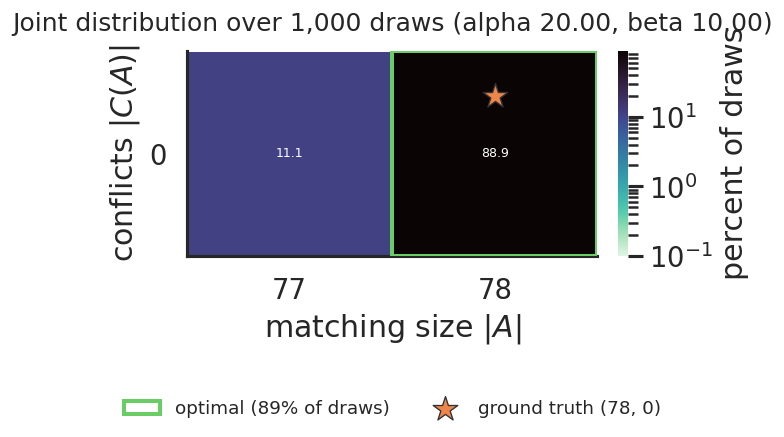

2 of 2 cells visited; 100.0% of draws are conflict free
|A| spans 77-78, conflicts span 0-0


In [6]:
# Where the ground truth sits in this plane. Masking only deletes produces edges, so a
# strain producing a metabolite always still carries its BGC and the true assignment is
# conflict free by construction. Including it in the axis limits keeps the comparison
# honest: if the chain never reaches that column, the plot has to show it.
truth_vec = np.full(N_m, -1, dtype=np.int32)
for i_, j_ in true_pairs:
    truth_vec[j_] = i_
gt_mask = truth_vec >= 0
gt_size = int(gt_mask.sum())
gt_conf = int(C[truth_vec[gt_mask], rows[gt_mask]].sum())
note("SAMPLER", "ground truth (|A|, conflicts)", f"({gt_size}, {gt_conf})")
note("SAMPLER", "draws reaching the ground-truth size", f"{(sizes == gt_size).mean():.1%}")

s_lo, s_hi = int(min(sizes.min(), gt_size)), int(max(sizes.max(), gt_size))
c_lo, c_hi = int(min(conflicts.min(), gt_conf)), int(max(conflicts.max(), gt_conf))
n_cols, n_rows = s_hi - s_lo + 1, c_hi - c_lo + 1
s_edges = np.arange(s_lo, s_hi + 2) - 0.5
c_edges = np.arange(c_lo, c_hi + 2) - 0.5
H, _, _ = np.histogram2d(sizes, conflicts, bins=[s_edges, c_edges])
Pjoint = 100 * H.T / H.sum()                 # rows are conflicts, columns are sizes

# Both axes count things, so the cells are square and the figure height follows the number
# of attainable conflict values rather than being fixed. With a large BETA that is a short
# strip, which is itself the result: the chain almost never buys size with a conflict.
fig, ax = plt.subplots(figsize=(11, 1.8 + 0.42 * n_cols * n_rows / max(n_cols, 1)))
mesh = ax.pcolormesh(s_edges, c_edges, np.where(Pjoint > 0, Pjoint, np.nan),
                     cmap=sns.color_palette("mako_r", as_cmap=True),
                     norm=LogNorm(vmin=100 / N_SAMPLES, vmax=Pjoint.max()),
                     edgecolors="white", linewidth=0.4)
ax.set_aspect("equal")
cb = fig.colorbar(mesh, ax=ax, fraction=0.025 * n_rows, pad=0.02)
cb.set_label("percent of draws")
cb.outline.set_visible(False)

# few enough cells to label, and the numbers are the point of the figure
for ci in range(n_rows):
    for si in range(n_cols):
        p = Pjoint[ci, si]
        if p <= 0:
            continue
        ax.text(s_lo + si, c_lo + ci, f"{p:.1f}" if p >= 0.05 else "<0.1",
                ha="center", va="center", fontsize=7.5,
                color="white" if mesh.norm(p) > 0.55 else "#222222")

# nothing is filtered now, so outline the optimal cell instead of a retained region
ax.add_patch(plt.Rectangle((MAX_SIZE - 0.5, -0.5), 1, 1,
                           fill=False, ec=COLORS["cupid"], lw=2.4, zorder=5,
                           label=f"optimal ({is_opt.mean():.0%} of draws)"))
# offset inside the cell so the star does not sit on top of its percentage label
ax.scatter([gt_size], [gt_conf + 0.28], marker="*", s=240, color=COLORS["molecule"],
           edgecolors="#333333", linewidths=0.8, zorder=6,
           label=f"ground truth ({gt_size}, {gt_conf})")
ax.legend(fontsize=11, loc="upper center", bbox_to_anchor=(0.5, -0.62), ncol=2)
ax.set_xticks(range(s_lo, s_hi + 1, 1 + n_cols // 14))
ax.set_yticks(range(c_lo, c_hi + 1))          # conflicts are counts, never fractional
ax.set_xlabel("matching size $|A|$")
ax.set_ylabel("conflicts $|C(A)|$")
ax.set_title(f"Joint distribution over {N_SAMPLES:,} draws "
             f"(alpha {ALPHA:.2f}, beta {BETA:.2f})", fontsize=15, pad=12)
ax.spines[["top", "right"]].set_visible(False)

joint_long = pd.DataFrame(
    [{"size": int(s), "conflicts": int(c), "percent": Pjoint[ci, si],
      "draws": int(H[si, ci])}
     for ci, c in enumerate(range(c_lo, c_hi + 1))
     for si, s in enumerate(range(s_lo, s_hi + 1))])
save_fig(fig, "part3_joint_distribution", joint_long)
plt.show()

occupied = int((H > 0).sum())
note("SAMPLER", "attainable (|A|, conflicts) cells visited", occupied)
note("SAMPLER", "draws with no conflict", f"{(conflicts == 0).mean():.1%}")
print(f"{occupied} of {H.size} cells visited; "
      f"{(conflicts == 0).mean():.1%} of draws are conflict free")
print(f"|A| spans {s_lo}-{s_hi}, conflicts span {c_lo}-{c_hi}")

## 4. Coverage

A true link that appears in no retained sample would mean the chain failed to reach part of the
feasible set, which is a statement about the sampler rather than about the link.

In [7]:
# NEW: the marginal is taken over every draw, not over a filtered subset
support = np.zeros((N_b, N_m))
for t in range(N_SAMPLES):
    m = samples[t] >= 0
    support[samples[t][m], rows[m]] += 1
support /= N_SAMPLES

true_list = sorted(true_pairs)
sup_true = np.array([support[i, j] for i, j in true_list])
seen = int((sup_true > 0).sum())
note("COVERAGE", "true links sampled at least once", f"{seen} of {len(true_list)}")
note("COVERAGE", "median support of a true link", f"{np.median(sup_true):.2f}")
note("COVERAGE", "true links with support above 0.5", int((sup_true > 0.5).sum()))
print(f"true links appearing in at least one retained sample: {seen} of {len(true_list)}")
for (i, j), s in zip(true_list, sup_true):
    if s == 0:
        print(f"   never sampled: {bgcs[i]} -> {mols[j]}")
print(f"support of a true link: median {np.median(sup_true):.2f}, "
      f"{int((sup_true > 0.5).sum())} above one half")

true links appearing in at least one retained sample: 78 of 78
support of a true link: median 1.00, 72 above one half


### One assignment, drawn like the baseline

Everything above is a property of the whole posterior. This is a single draw from it, plotted in
exactly the style notebook 03 uses for its predictions, so the two figures can be laid side by side.

The draw is the strongest thing the sampler produces, a matching with an empty conflict set and no
smaller than any other conflict-free draw. Ties are broken with the global seed. Unlike the
baseline it is a matching by construction, so it can never credit one BGC with two metabolites, and
the only errors it can make are picking the wrong producer or leaving a metabolite unexplained.

889 of 1,000 draws are optimal at size 78; drawing one of them


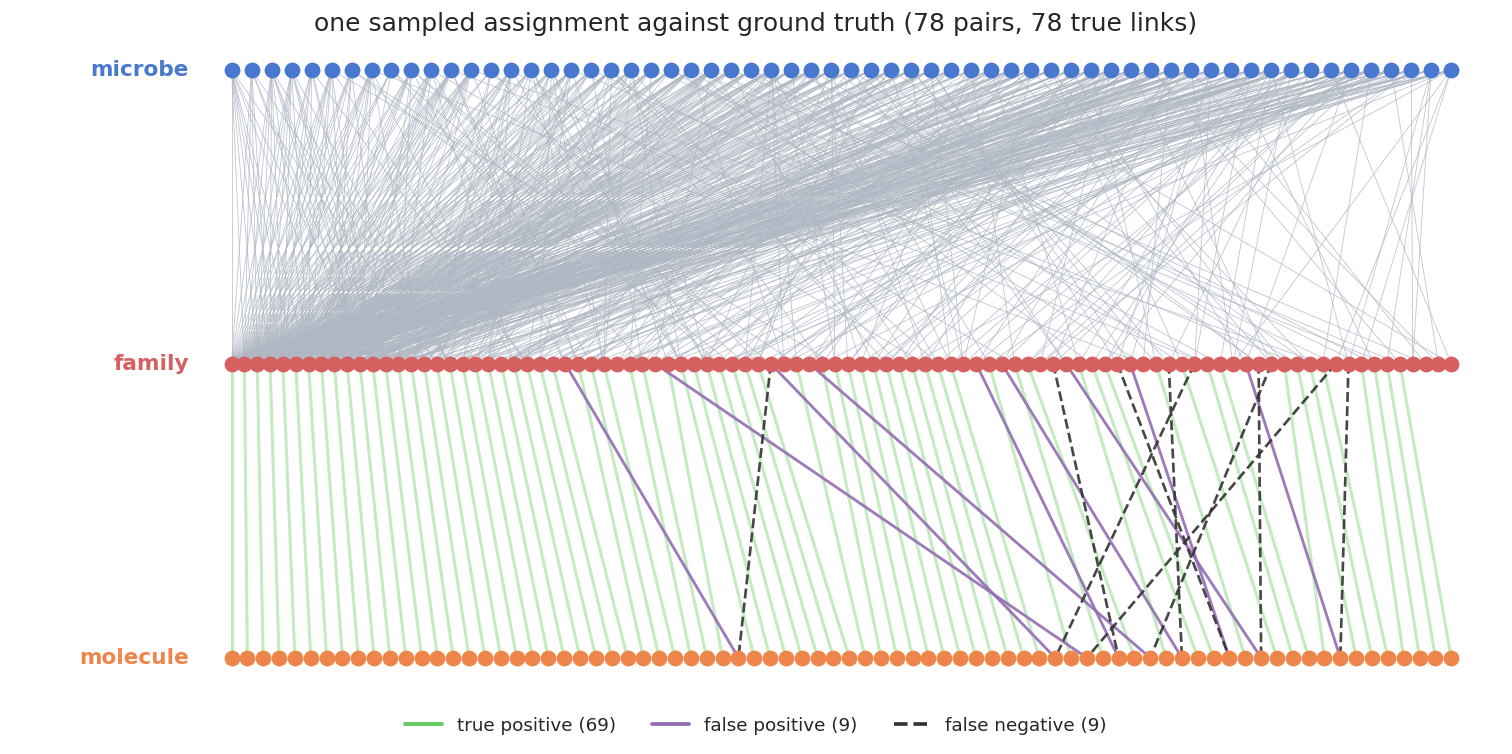

{'true positive': 69, 'false positive': 9, 'false negative': 9}


In [8]:
# pick one optimal assignment, meaning conflict free and of maximum size
elig = np.flatnonzero(is_opt)
pick = int(np.random.default_rng(SEED).choice(elig))
assign = samples[pick]
note("ASSIGNMENT GRAPH", "optimal draws to choose from", len(elig))
note("ASSIGNMENT GRAPH", "size of the drawn assignment", int(sizes[pick]))
print(f"{len(elig):,} of {N_SAMPLES:,} draws are optimal at size {MAX_SIZE}; "
      f"drawing one of them")

pred_pairs = {(bgcs[int(assign[j])], mols[j]) for j in range(N_m) if assign[j] >= 0}
true_named = {(bgcs[i], mols[j]) for i, j in true_pairs}
edge_class = {}
for e in pred_pairs | true_named:
    edge_class[e] = ("true positive" if e in pred_pairs and e in true_named
                     else "false positive" if e in pred_pairs else "false negative")

ROWS = ["microbe", "family", "molecule"]
# identical to notebook 03: the two error classes are what the figure is for, so they sit
# on top and stay opaque while the correct edges recede
STYLE = {
    "true positive":  dict(color=_MUTED[2], lw=1.8, ls="-",  alpha=0.40, z=2),
    "false positive": dict(color=_MUTED[4], lw=1.7, ls="-",  alpha=0.90, z=4),
    "false negative": dict(color="#333333", lw=1.6, ls="--", alpha=0.90, z=5),
}


def layered_pos(H, rows, anchor):
    # an anchor row placed by degree, the others at their neighbours' barycentre
    ys = {t: 1.0 - i for i, t in enumerate(rows)}
    pos = {}
    anch = sorted([n for n, d in H.nodes(data=True) if d["ntype"] == anchor],
                  key=lambda n: (-H.degree(n), str(n)))
    d0 = max(len(anch) - 1, 1)
    for i, n in enumerate(anch):
        pos[n] = (i / d0, ys[anchor])
    for t in rows:
        if t == anchor:
            continue
        members = sorted([n for n, dd in H.nodes(data=True) if dd["ntype"] == t], key=str)
        bary = {n: np.mean([pos[v][0] for v in H.neighbors(n) if v in pos] or [0.5])
                for n in members}
        ranked = sorted(members, key=lambda n: (bary[n], str(n)))
        d1 = max(len(ranked) - 1, 1)
        for i, n in enumerate(ranked):
            pos[n] = (i / d1, ys[t])
    return pos


def plot_links(node_filter=None, title="", name="", figsize=(16, 7),
               carries_width=0.5, node_size=90):
    H = nx.Graph()
    for n in strains:
        H.add_node(n, ntype="microbe")
    for n in bgcs:
        H.add_node(n, ntype="family")
    for n in mols:
        H.add_node(n, ntype="molecule")
    for u, v, d in G_masked.edges(data=True):
        if d["etype"] == "carries":
            H.add_edge(u, v, etype="carries")
    for (f, m), cls in edge_class.items():
        H.add_edge(f, m, etype=cls)
    if node_filter is not None:
        H = H.subgraph(node_filter).copy()

    pos = layered_pos(H, ROWS, anchor="family")
    fig, ax = plt.subplots(figsize=figsize)
    for u, v, d in H.edges(data=True):          # carries first, underneath
        if d["etype"] != "carries":
            continue
        (x0, y0), (x1, y1) = pos[u], pos[v]
        ax.plot([x0, x1], [y0, y1], lw=carries_width, color="#b0b7c3",
                alpha=0.8, zorder=1)
    counts = Counter()
    for u, v, d in sorted(H.edges(data=True),
                          key=lambda e: STYLE.get(e[2]["etype"], {}).get("z", 0)):
        st = STYLE.get(d["etype"])
        if st is None:
            continue
        counts[d["etype"]] += 1
        (x0, y0), (x1, y1) = pos[u], pos[v]
        ax.plot([x0, x1], [y0, y1], lw=st["lw"], color=st["color"],
                ls=st["ls"], alpha=st["alpha"], zorder=st["z"])
    for t in ROWS:
        ns = [n for n, d in H.nodes(data=True) if d["ntype"] == t]
        ax.scatter([pos[n][0] for n in ns], [pos[n][1] for n in ns],
                   s=node_size, color=COLORS[t], zorder=5, linewidths=0)
        ax.text(-0.035, 1.0 - ROWS.index(t), t, ha="right", va="center",
                fontsize=13, color=COLORS[t], fontweight="bold")
    handles = [plt.Line2D([], [], color=STYLE[k]["color"], lw=STYLE[k]["lw"] + 0.6,
                          ls=STYLE[k]["ls"], alpha=1.0, label=f"{k} ({counts[k]})")
               for k in STYLE]
    ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.02),
              ncol=3, fontsize=11)
    ax.set_xlim(-0.18, 1.04)
    ax.axis("off")
    ax.set_title(title, fontsize=15)

    df = pd.DataFrame([{"bgc": u if H.nodes[u]["ntype"] == "family" else v,
                        "molecule": v if H.nodes[u]["ntype"] == "family" else u,
                        "edge_class": d["etype"],
                        "x_bgc": pos[u if H.nodes[u]["ntype"] == "family" else v][0],
                        "x_molecule": pos[v if H.nodes[u]["ntype"] == "family" else u][0]}
                       for u, v, d in H.edges(data=True) if d["etype"] in STYLE])
    save_fig(fig, name, df.sort_values(["edge_class", "bgc", "molecule"]))
    plt.show()
    return counts


counts_full = plot_links(
    title=f"one sampled assignment against ground truth "
          f"({len(pred_pairs)} pairs, {len(true_named)} true links)",
    name="part4_assignment_graph")
for k_ in STYLE:
    note("ASSIGNMENT GRAPH", k_, counts_full[k_])
note("ASSIGNMENT GRAPH", "precision of the drawn assignment",
     f"{counts_full['true positive'] / max(len(pred_pairs), 1):.0%}")
print({k_: counts_full[k_] for k_ in STYLE})

### The same slice as notebooks 01 and 03

Restricted to the same genomes, using an identical selection, so all three figures line up.

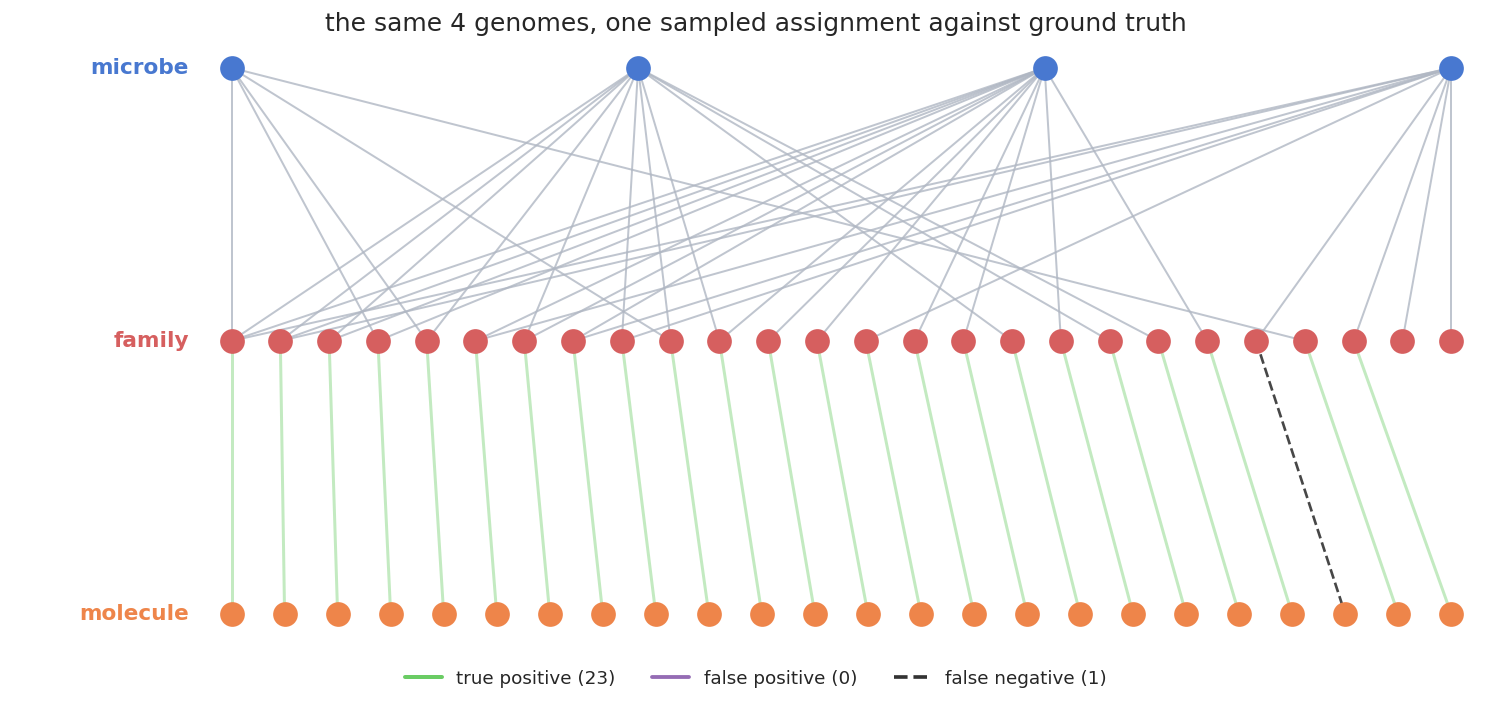

{'true positive': 23, 'false positive': 0, 'false negative': 1}


In [9]:
# identical selection to notebooks 01 and 03: same seed, same sorted strain list
N_SUBSET_STRAINS, SUBSET_SEED = 4, 0
picked = sorted(np.random.default_rng(SUBSET_SEED)
                .choice(sorted(strains), size=N_SUBSET_STRAINS, replace=False).tolist())
keep_nodes = set(picked)
for m_ in picked:
    for f in G_truth.neighbors(m_):
        if G_truth.nodes[f]["ntype"] != "family":
            continue
        keep_nodes.add(f)
        keep_nodes.update(x for x in G_truth.neighbors(f)
                          if G_truth.nodes[x]["ntype"] == "molecule")

counts_sub = plot_links(node_filter=keep_nodes, figsize=(16, 6.5),
                        carries_width=1.2, node_size=220,
                        title=f"the same {N_SUBSET_STRAINS} genomes, "
                              f"one sampled assignment against ground truth",
                        name="part4_assignment_graph_subset")
print({k_: counts_sub[k_] for k_ in STYLE})

## 5. The summary graph

The description length of a clustering is the sum over block pairs of the entropy of its edge-count
histogram plus the expected log number of edge placements consistent with that count. The first term
charges for histograms that are spread out, the second for clusters so large that many placements
look alike.

Two facts make this cheap to maintain. A block pair empty in every sample contributes nothing, so
only non-empty cells are tracked. And a matching gives every node degree at most one, so moving a
node changes one cell per sample.

In [10]:
MAXK = min(N_b, N_m) + 2
LOGF = np.concatenate([[0.0], np.cumsum(np.log2(np.arange(1, MAXK + 1)))])


def log2_binom(n, k):
    return -np.inf if k < 0 or k > n else LOGF[n] - LOGF[k] - LOGF[n - k]


def cell_term(hist, r, c):
    # bits for one block pair: entropy of its count histogram plus the expected
    # log-count of edge placements consistent with that count
    tot = hist.sum()
    if tot == 0:
        return 0.0
    out = 0.0
    for k in np.flatnonzero(hist):
        p = hist[k] / tot
        out += p * (-math.log2(p) + log2_binom(r, int(k)) + log2_binom(c, int(k))
                    + LOGF[int(k)])
    return out


class Summary:
    '''Block-count bookkeeping for one clustering, updated incrementally.'''

    def __init__(self, kept, cb, cm):
        self.T = len(kept)
        self.cb, self.cm = cb.copy(), cm.copy()
        self.sb = np.bincount(self.cb, minlength=N_b).astype(np.int64)
        self.sm = np.bincount(self.cm, minlength=N_m).astype(np.int64)
        self.owner = kept                       # T x N_m : BGC of each metabolite
        self.partner = np.full((self.T, N_b), -1, dtype=np.int32)
        for t in range(self.T):
            m = kept[t] >= 0
            self.partner[t, kept[t][m]] = np.flatnonzero(m)
        self.cnt, self.hist, self.term = {}, {}, {}
        self.by_row, self.by_col = defaultdict(set), defaultdict(set)
        # build each cell in one shot; a block pair can take several edges in the
        # same sample, so the counts are tallied rather than incremented one by one
        ts, isx = np.nonzero(self.partner >= 0)
        Ps, Qs = self.cb[isx], self.cm[self.partner[ts, isx]]
        cells = Ps * (N_m + 1) + Qs
        for cell in np.unique(cells):
            sel = ts[cells == cell]
            P, Q = int(cell) // (N_m + 1), int(cell) % (N_m + 1)
            key = self._cell(P, Q)
            counts = np.bincount(sel, minlength=self.T).astype(np.int32)
            self.cnt[key] = counts
            self.hist[key] = np.bincount(counts, minlength=MAXK).astype(np.int64)
        for key in list(self.cnt):
            self._retally(key)
        self.q = sum(self.term.values())

    def _cell(self, P, Q):
        key = (P, Q)
        if key not in self.cnt:
            self.cnt[key] = np.zeros(self.T, dtype=np.int32)
            self.hist[key] = np.zeros(MAXK, dtype=np.int64)
            self.hist[key][0] = self.T
            self.term[key] = 0.0
            self.by_row[P].add(Q)
            self.by_col[Q].add(P)
        return key

    def _bulk(self, P, Q, sel, d):
        # shift the counts of the given samples for one cell, and repair its
        # histogram in two bincounts rather than one pass per sample
        key = self._cell(P, Q)
        arr, h = self.cnt[key], self.hist[key]
        old = arr[sel]
        new = old + d
        arr[sel] = new
        h -= np.bincount(old, minlength=MAXK)
        h += np.bincount(new, minlength=MAXK)

    def _retally(self, key):
        P, Q = key
        old = self.term.get(key, 0.0)
        new = cell_term(self.hist[key], int(self.sb[P]), int(self.sm[Q]))
        self.term[key] = new
        return new - old

    def move(self, side, node, dest):
        '''Move one node into another cluster and return the change in q.'''
        if side == "b":
            src = int(self.cb[node])
            if src == dest:
                return 0.0
            ts = np.flatnonzero(self.partner[:, node] >= 0)
            qs = self.cm[self.partner[ts, node]]
            for Q in np.unique(qs):
                sel = ts[qs == Q]
                self._bulk(src, int(Q), sel, -1)
                self._bulk(dest, int(Q), sel, +1)
            self.cb[node] = dest
            self.sb[src] -= 1
            self.sb[dest] += 1
            touched = ([(src, Q) for Q in self.by_row[src]]
                       + [(dest, Q) for Q in self.by_row[dest]])
        else:
            src = int(self.cm[node])
            if src == dest:
                return 0.0
            ts = np.flatnonzero(self.owner[:, node] >= 0)
            ps = self.cb[self.owner[ts, node]]
            for P in np.unique(ps):
                sel = ts[ps == P]
                self._bulk(int(P), src, sel, -1)
                self._bulk(int(P), dest, sel, +1)
            self.cm[node] = dest
            self.sm[src] -= 1
            self.sm[dest] += 1
            touched = ([(P, src) for P in self.by_col[src]]
                       + [(P, dest) for P in self.by_col[dest]])
        delta = sum(self._retally(k) for k in set(touched))
        self.q += delta
        return delta

    def model_bits(self):
        # cost of transmitting the summary graph: which cluster each node is in,
        # plus one histogram per non-empty block pair. Without this the model is
        # free and no merge ever pays for itself.
        kb = max(int((self.sb > 0).sum()), 1)
        km = max(int((self.sm > 0).sum()), 1)
        params = 0
        for h in self.hist.values():
            if h[1:].any():
                params += max(int((h > 0).sum()) - 1, 0)
        return (N_b * math.log2(kb) + N_m * math.log2(km)
                + 0.5 * params * math.log2(max(self.T, 2)))

    def total(self):
        return self.q + LAMBDA_MODEL * self.model_bits()

    def snapshot(self):
        return self.cb.copy(), self.cm.copy(), self.total()

In [11]:
def relabel(lab):
    _, out = np.unique(lab, return_inverse=True)
    return out.astype(np.int64)


def initial_clustering(support):
    # Starting from singletons does not work: merging two BGCs saves the entropy
    # of "which of the two" but pays exactly one bit for the extra placement, so
    # pairwise merges are flat and only merging a whole competitor set pays off.
    # Single-node moves cannot cross that plateau, so we start from a grouping
    # that already reflects the competition: BGCs that share the metabolite they
    # most often take, and metabolites that share the BGC that most often takes
    # them. Everything unmatched stays on its own.
    cb = np.arange(N_b, dtype=np.int64)
    cm = np.arange(N_m, dtype=np.int64)
    hot_b, hot_m = support.max(1), support.max(0)
    cb[hot_b > 0] = N_m + support.argmax(1)[hot_b > 0]
    cm[hot_m > 0] = N_b + support.argmax(0)[hot_m > 0]
    return relabel(cb), relabel(cm)


def cluster_chain(kept, steps=N_CLUSTER_STEPS, seed=SEED, start=None):
    rng = np.random.default_rng(seed)
    cb0, cm0 = start if start is not None else (np.arange(N_b), np.arange(N_m))
    S = Summary(kept, np.asarray(cb0), np.asarray(cm0))
    best = S.snapshot()
    trace = np.empty(steps)
    accepted = 0
    for step in range(steps):
        temp = TEMP_START * (TEMP_END / TEMP_START) ** (step / max(steps - 1, 1))
        side = "b" if rng.random() < N_b / (N_b + N_m) else "m"
        lab, sizes_ = (S.cb, S.sb) if side == "b" else (S.cm, S.sm)
        node = int(rng.integers(0, len(lab)))
        src = int(lab[node])
        live = np.flatnonzero(sizes_ > 0)
        free = np.flatnonzero(sizes_ == 0)
        targets = np.concatenate([live, free[:1]]) if len(free) else live
        targets = targets[targets != src]
        if not len(targets):
            trace[step] = S.q
            continue
        dest = int(rng.choice(targets))
        k_before = int((sizes_ > 0).sum())
        before = S.total()
        S.move(side, node, dest)
        delta = S.total() - before
        k_after = int(((S.sb if side == "b" else S.sm) > 0).sum())
        # Metropolis-Hastings: the k/k' factor corrects for emptying or creating a
        # cluster, which changes how many targets the reverse move can pick from
        ratio = (2.0 ** (-delta / temp)) * (k_before / k_after)
        if delta <= 0 or rng.random() < ratio:
            accepted += 1
            if S.total() < best[2] - 1e-12:
                best = S.snapshot()
        else:
            S.move(side, node, src)
        trace[step] = S.q
    return best, trace, accepted / steps


# Two nodes are worth trying in the same cluster only if they ever compete, that
# is if they take the same partner in some sample. Uniform proposals would try a
# given merge roughly once in the whole run, so the annealed chain is followed by
# a greedy sweep restricted to these neighbours.
takers = [set(np.unique(kept[:, j])) - {-1} for j in range(N_m)]
nb_b = [set() for _ in range(N_b)]
nb_m = [set() for _ in range(N_m)]
for j, tk in enumerate(takers):
    for i in tk:
        nb_b[int(i)] |= tk
for t in range(len(kept)):
    m = kept[t] >= 0
    for i in np.unique(kept[t][m]):
        js = np.flatnonzero(m & (kept[t] == i))
        for j in js:
            nb_m[int(j)] |= set(np.flatnonzero((kept == i).any(0)).tolist())
for i in range(N_b):
    nb_b[i].discard(i)
for j in range(N_m):
    nb_m[j].discard(j)


def greedy_refine(S, max_sweeps=8):
    for _ in range(max_sweeps):
        gained = 0.0
        for side, node in ([("b", i) for i in range(N_b)]
                           + [("m", j) for j in range(N_m)]):
            lab = S.cb if side == "b" else S.cm
            sizes_ = S.sb if side == "b" else S.sm
            src = int(lab[node])
            nbs = nb_b[node] if side == "b" else nb_m[node]
            cand = {int(lab[x]) for x in nbs}
            free = np.flatnonzero(sizes_ == 0)
            if len(free):
                cand.add(int(free[0]))
            cand.discard(src)
            base = S.total()
            best_d, best_dest = -1e-9, None
            for dest in sorted(cand):
                S.move(side, node, dest)
                d = S.total() - base
                if d < best_d:
                    best_d, best_dest = d, dest
                S.move(side, node, src)
            if best_dest is not None:
                S.move(side, node, best_dest)
                gained += best_d
        if gained > -1e-9:
            break
    return S


# Every description length reported here is a total, data term plus LAMBDA_MODEL times the
# model term, because that is what the chain minimizes. Quoting the data term alone inverts
# the result: merging deliberately pays a larger data cost to buy a much smaller model, so
# the data term rises while the total falls.
S_single = Summary(kept, np.arange(N_b), np.arange(N_m))
q_singletons = S_single.total()
start = initial_clustering(support)
q_start = Summary(kept, *start).total()
(best_cb, best_cm, best_q), trace, cl_acc = cluster_chain(kept, start=start)
S = Summary(kept, best_cb, best_cm)
q_annealed = S.total()
note("SUMMARY GRAPH", "bits, all singletons", f"{q_singletons:.1f}")
note("SUMMARY GRAPH", "bits, initial clustering", f"{q_start:.1f}")
print(f"description length: {q_singletons:.1f} bits at singletons, "
      f"{q_start:.1f} after initialization")
S = greedy_refine(S)
best_cb, best_cm, best_q = S.cb.copy(), S.cm.copy(), S.total()
note("SUMMARY GRAPH", "bits after annealing", f"{q_annealed:.1f}")
note("SUMMARY GRAPH", "bits after greedy refinement", f"{best_q:.1f}")
note("SUMMARY GRAPH", "compression against singletons", f"{q_singletons / best_q:.2f}x")
note("SUMMARY GRAPH", "bits, data term", f"{S.q:.1f}")
note("SUMMARY GRAPH", "bits, model term", f"{S.model_bits():.1f}")
note("SUMMARY GRAPH", "bits at singletons, data term", f"{S_single.q:.1f}")
note("SUMMARY GRAPH", "bits at singletons, model term", f"{S_single.model_bits():.1f}")
print(f"description length: {q_annealed:.1f} bits after annealing, {best_q:.1f} after "
      f"greedy refinement ({q_singletons / best_q:.2f}x smaller than singletons)")
print(f"  split: data {S.q:.1f} + model {S.model_bits():.1f}, against "
      f"data {S_single.q:.1f} + model {S_single.model_bits():.1f} at singletons")
k_b = int((S.sb > 0).sum())
k_m = int((S.sm > 0).sum())
det = sum(1 for key, h in S.hist.items() if int((h > 0).sum()) == 1 and S.cnt[key].max() > 0)
var = sum(1 for key, h in S.hist.items() if int((h > 0).sum()) > 1)

note("SUMMARY GRAPH", "clustering acceptance rate", f"{cl_acc:.1%}")
note("SUMMARY GRAPH", "description length (bits)", f"{best_q:.1f}")
note("SUMMARY GRAPH", "BGC clusters", k_b)
note("SUMMARY GRAPH", "metabolite clusters", k_m)
note("SUMMARY GRAPH", "block pairs with a fixed count", det)
note("SUMMARY GRAPH", "block pairs with a varying count", var)
print(f"clustering: {k_b} BGC clusters, {k_m} metabolite clusters, "
      f"q = {best_q:.1f} bits, acceptance {cl_acc:.1%}")
print(f"block pairs: {det} with a fixed count, {var} with a varying count")

description length: 1810.5 bits at singletons, 1438.2 after initialization


description length: 959.7 bits after annealing, 959.1 after greedy refinement (1.89x smaller than singletons)
  split: data 180.1 + model 779.0, against data 40.3 + model 1770.2 at singletons
clustering: 16 BGC clusters, 18 metabolite clusters, q = 959.1 bits, acceptance 28.8%
block pairs: 18 with a fixed count, 8 with a varying count


Two claims from the paper are properties of the summary graph rather than of the raw samples, so
they are checked here. A true pair is **possible** if the block pair containing it ever carries an
edge, and **determined** if that block pair is a singleton on both sides with a fixed count.

In [12]:
possible, determined, ambiguous = 0, 0, []
for i, j in true_list:
    P, Q = int(best_cb[i]), int(best_cm[j])
    h = S.hist.get((P, Q))
    if h is None or int(np.flatnonzero(h)[-1]) == 0:
        continue
    possible += 1
    if int(S.sb[P]) == 1 and int(S.sm[Q]) == 1 and int((h > 0).sum()) == 1:
        determined += 1
    else:
        ambiguous.append((i, j, int(S.sb[P]), int(S.sm[Q])))

# "determined" is strict: the block pair must be a singleton on both sides and
# carry the same count in every sample, so the link holds with no alternative.
# The softer count reports links the summary graph places with high confidence
# without ruling every competitor out.
near = int((sup_true >= 0.9).sum())
half = int((sup_true >= 0.5).sum())
note("SUMMARY GRAPH", "true links still possible", f"{possible} of {len(true_list)}")
note("SUMMARY GRAPH", "true links determined", determined)
note("SUMMARY GRAPH", "true links left ambiguous", len(ambiguous))
note("SUMMARY GRAPH", "true links with support at least 0.9", near)
note("SUMMARY GRAPH", "true links with support at least 0.5", half)
print(f"true links still possible under the summary graph: {possible} of {len(true_list)}")
print(f"   determined by it : {determined}")
print(f"   left ambiguous   : {len(ambiguous)}")
print(f"   support at least 0.9: {near}, at least 0.5: {half}")
if ambiguous:
    bs = np.array([[a, b] for *_, a, b in ambiguous])
    print(f"   ambiguous ones sit in blocks of median size "
          f"{np.median(bs[:, 0]):.0f} (BGC) by {np.median(bs[:, 1]):.0f} (metabolite)")

true links still possible under the summary graph: 78 of 78
   determined by it : 0
   left ambiguous   : 78
   support at least 0.9: 64, at least 0.5: 72
   ambiguous ones sit in blocks of median size 5 (BGC) by 5 (metabolite)


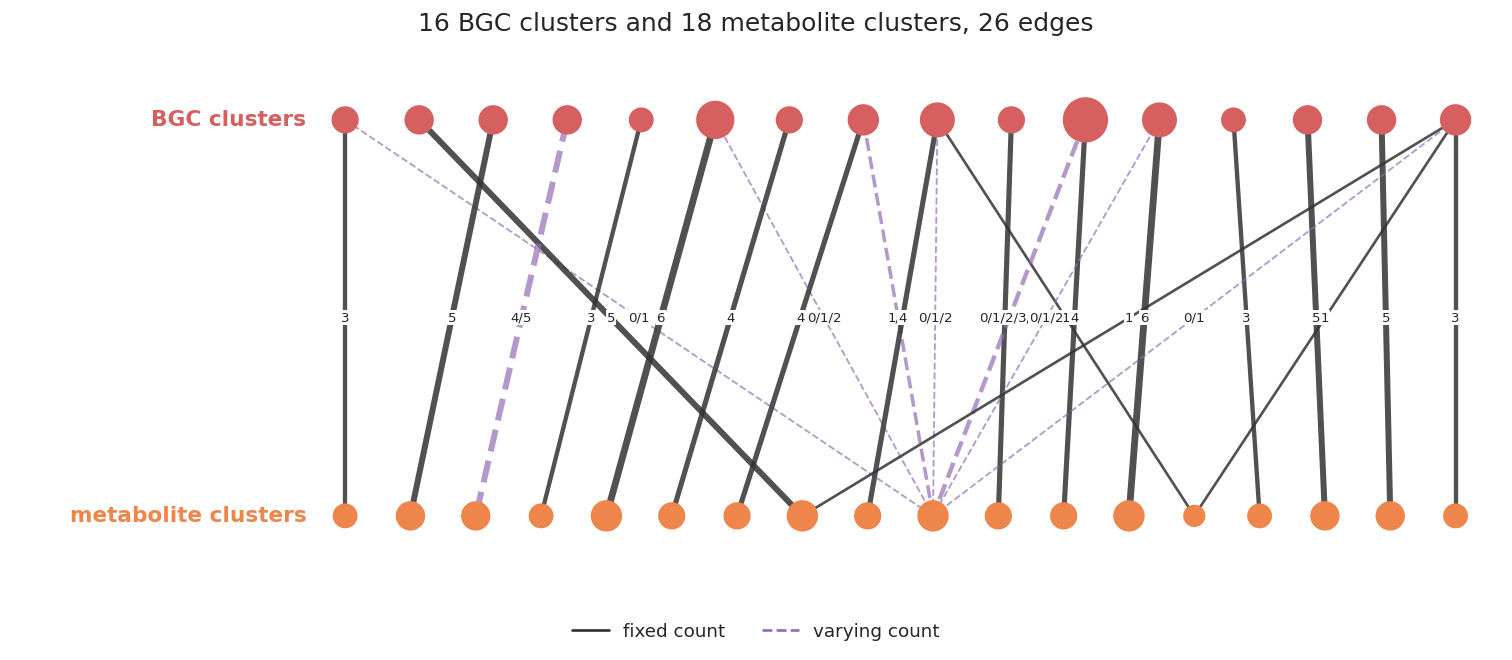

In [13]:
# the summary graph: one node per cluster, one edge per block pair that ever
# carries an edge, solid where the count never varies and dashed where it does
cells = [(P, Q) for (P, Q), h in sorted(S.hist.items())
         if len(np.flatnonzero(h)) and int(np.flatnonzero(h)[-1]) > 0]
Pb = sorted({P for P, _ in cells})
Qm = sorted({Q for _, Q in cells})
xb = {P: k / max(len(Pb) - 1, 1) for k, P in enumerate(Pb)}
bary = {Q: np.mean([xb[P] for P, Q2 in cells if Q2 == Q]) for Q in Qm}
xm = {Q: k / max(len(Qm) - 1, 1)
      for k, Q in enumerate(sorted(Qm, key=lambda q: (bary[q], q)))}

fig, ax = plt.subplots(figsize=(16, 6))
rowsout = []
for P, Q in cells:
    h = S.hist[(P, Q)]
    vals = np.flatnonzero(h)
    fixed = len(vals) == 1
    mode = int(vals[np.argmax(h[vals])])
    ax.plot([xb[P], xm[Q]], [1, 0], lw=1.1 + 0.5 * mode,
            color="#333333" if fixed else COLORS["baseline"],
            ls="-" if fixed else "--", alpha=0.85 if fixed else 0.7, zorder=2)
    ax.text((xb[P] + xm[Q]) / 2, 0.5,
            str(mode) if fixed else "/".join(str(int(v)) for v in vals),
            fontsize=8, ha="center", va="center",
            bbox=dict(fc="white", ec="none", pad=0.6), zorder=3)
    rowsout.append({"bgc_cluster": P, "metabolite_cluster": Q,
                    "bgc_cluster_size": int(S.sb[P]),
                    "metabolite_cluster_size": int(S.sm[Q]),
                    "counts": "/".join(str(int(v)) for v in vals),
                    "frequencies": "/".join(f"{h[v] / T:.3f}" for v in vals),
                    "deterministic": fixed, "x_bgc": xb[P], "x_metabolite": xm[Q]})
ax.scatter([xb[P] for P in Pb], [1] * len(Pb),
           s=60 + 40 * np.array([S.sb[P] for P in Pb]), color=COLORS["family"], zorder=4)
ax.scatter([xm[Q] for Q in Qm], [0] * len(Qm),
           s=60 + 40 * np.array([S.sm[Q] for Q in Qm]), color=COLORS["molecule"], zorder=4)
ax.text(-0.035, 1, "BGC clusters", ha="right", va="center", fontsize=13,
        color=COLORS["family"], fontweight="bold")
ax.text(-0.035, 0, "metabolite clusters", ha="right", va="center", fontsize=13,
        color=COLORS["molecule"], fontweight="bold")
h1 = plt.Line2D([], [], color="#333333", lw=1.6, label="fixed count")
h2 = plt.Line2D([], [], color=COLORS["baseline"], lw=1.6, ls="--", label="varying count")
ax.legend(handles=[h1, h2], loc="upper center", bbox_to_anchor=(0.5, -0.02),
          ncol=2, fontsize=11)
ax.set_xlim(-0.3, 1.04)
ax.set_ylim(-0.2, 1.2)
ax.axis("off")
ax.set_title(f"{k_b} BGC clusters and {k_m} metabolite clusters, "
             f"{len(cells)} edges", fontsize=15)
save_fig(fig, "part5_summary_graph", pd.DataFrame(rowsout))
plt.show()

### The same summary graph, unrolled over the original nodes

The figure above draws only the blocks, so it is compact but says nothing about which BGCs and
which metabolites a block actually contains. This version keeps all four levels visible.

The outer rows hold the individual BGCs and metabolites, ordered so that members of a cluster are
adjacent and the largest cluster comes first on each side. The two inner rows hold the clusters
themselves, drawn in a darker shade of the same colour, with each cluster placed above or below its
own members. Between the two inner rows sit the block edges: **width** is the mean number of
assignment edges the block carries across the retained samples, and **opacity** is the variance of
that count, so a fully opaque link always carries the same number of edges and a faint one is a
block the samples disagree about.

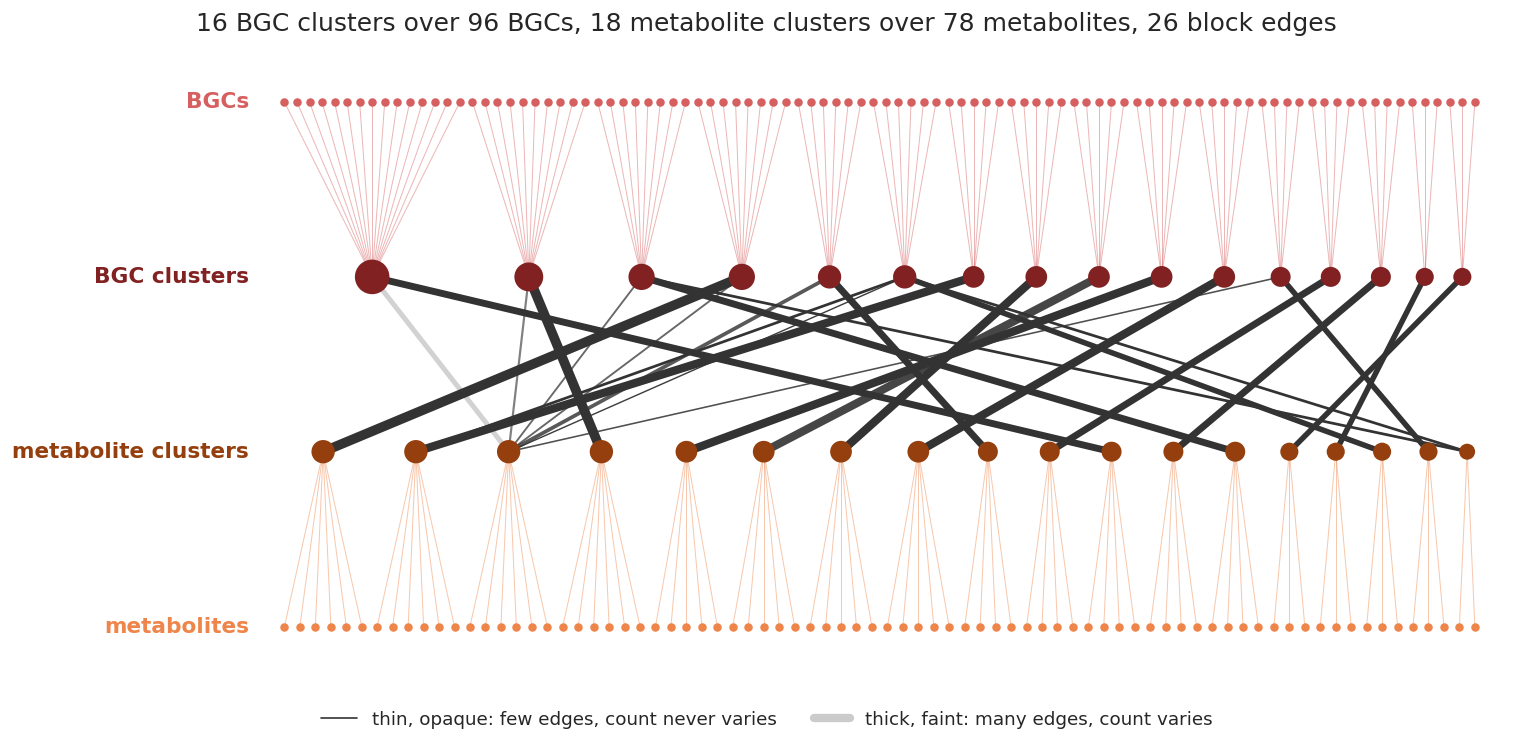

26 block edges | mean edge count 0.05-6.00 | variance 0-0.85
largest clusters: 15 BGCs, 6 metabolites


In [14]:
b_lab, m_lab = np.asarray(S.cb), np.asarray(S.cm)
b_order = sorted({int(p) for p in b_lab}, key=lambda p: (-int(S.sb[p]), p))
m_order = sorted({int(q) for q in m_lab}, key=lambda q: (-int(S.sm[q]), q))

# members contiguous, largest cluster first, names breaking ties so the layout is fixed
b_seq = [i for p in b_order
         for i in sorted(np.flatnonzero(b_lab == p).tolist(), key=lambda i: bgcs[i])]
m_seq = [j for q in m_order
         for j in sorted(np.flatnonzero(m_lab == q).tolist(), key=lambda j: mols[j])]
xb = {i: k / max(len(b_seq) - 1, 1) for k, i in enumerate(b_seq)}
xm = {j: k / max(len(m_seq) - 1, 1) for k, j in enumerate(m_seq)}
xbc = {p: float(np.mean([xb[i] for i in np.flatnonzero(b_lab == p)])) for p in b_order}
xmc = {q: float(np.mean([xm[j] for j in np.flatnonzero(m_lab == q)])) for q in m_order}

# mean and variance of the edge count of every non-empty block
blocks = []
for (P, Q), c in sorted(S.cnt.items()):
    mu, var = float(c.mean()), float(c.var())
    if mu > 0:
        blocks.append({"bgc_cluster": int(P), "metabolite_cluster": int(Q),
                       "mean_edges": mu, "variance": var})
mu_max = max(b["mean_edges"] for b in blocks)
var_max = max(b["variance"] for b in blocks)

C_B, C_M = COLORS["family"], COLORS["molecule"]
C_BC = sns.set_hls_values(C_B, l=0.32)          # same hue, darker, for the cluster rows
C_MC = sns.set_hls_values(C_M, l=0.32)
Y_B, Y_BC, Y_MC, Y_M = 3.0, 2.0, 1.0, 0.0

fig, ax = plt.subplots(figsize=(16, 7))
# membership links, kept faint so the block edges dominate
for i in range(N_b):
    ax.plot([xb[i], xbc[int(b_lab[i])]], [Y_B, Y_BC], lw=0.6, color=C_B, alpha=0.45, zorder=1)
for j in range(N_m):
    ax.plot([xm[j], xmc[int(m_lab[j])]], [Y_M, Y_MC], lw=0.6, color=C_M, alpha=0.45, zorder=1)
# block edges: width is the mean count, opacity falls with its variance
for b in blocks:
    a = 1.0 - 0.78 * (b["variance"] / var_max if var_max > 0 else 0.0)
    ax.plot([xbc[b["bgc_cluster"]], xmc[b["metabolite_cluster"]]], [Y_BC, Y_MC],
            lw=0.8 + 5.0 * b["mean_edges"] / mu_max, color="#333333", alpha=a, zorder=3,
            solid_capstyle="round")

ax.scatter([xb[i] for i in range(N_b)], [Y_B] * N_b, s=26, color=C_B, zorder=5, linewidths=0)
ax.scatter([xm[j] for j in range(N_m)], [Y_M] * N_m, s=26, color=C_M, zorder=5, linewidths=0)
ax.scatter([xbc[p] for p in b_order], [Y_BC] * len(b_order),
           s=[40 + 26 * int(S.sb[p]) for p in b_order], color=C_BC, zorder=6, linewidths=0)
ax.scatter([xmc[q] for q in m_order], [Y_MC] * len(m_order),
           s=[40 + 26 * int(S.sm[q]) for q in m_order], color=C_MC, zorder=6, linewidths=0)

for y_, lab, col in ((Y_B, "BGCs", C_B), (Y_BC, "BGC clusters", C_BC),
                     (Y_MC, "metabolite clusters", C_MC), (Y_M, "metabolites", C_M)):
    ax.text(-0.03, y_, lab, ha="right", va="center", fontsize=13,
            color=col, fontweight="bold")
handles = [plt.Line2D([], [], color="#333333", lw=1.0, alpha=1.0,
                      label=f"thin, opaque: few edges, count never varies"),
           plt.Line2D([], [], color="#333333", lw=5.0, alpha=0.25,
                      label=f"thick, faint: many edges, count varies")]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.01),
          ncol=2, fontsize=11)
ax.set_xlim(-0.22, 1.03)
ax.set_ylim(-0.35, 3.35)
ax.axis("off")
ax.set_title(f"{len(b_order)} BGC clusters over {N_b} BGCs, "
             f"{len(m_order)} metabolite clusters over {N_m} metabolites, "
             f"{len(blocks)} block edges", fontsize=15)

edges_df = pd.DataFrame(blocks)
edges_df["opacity"] = 1.0 - 0.78 * (edges_df["variance"] / var_max if var_max > 0 else 0.0)
edges_df["x_bgc_cluster"] = edges_df["bgc_cluster"].map(xbc)
edges_df["x_metabolite_cluster"] = edges_df["metabolite_cluster"].map(xmc)
edges_df["kind"] = "block"
mem = pd.DataFrame(
    [{"kind": "bgc", "node": bgcs[i], "cluster": int(b_lab[i]), "x": xb[i]}
     for i in b_seq]
    + [{"kind": "metabolite", "node": mols[j], "cluster": int(m_lab[j]), "x": xm[j]}
       for j in m_seq])
save_fig(fig, "part5_summary_graph_layered",
         pd.concat([edges_df, mem], ignore_index=True))
plt.show()

note("SUMMARY GRAPH", "block edges drawn (layered view)", len(blocks))
note("SUMMARY GRAPH", "largest BGC cluster", int(max(S.sb)))
note("SUMMARY GRAPH", "largest metabolite cluster", int(max(S.sm)))
print(f"{len(blocks)} block edges | mean edge count {min(b['mean_edges'] for b in blocks):.2f}"
      f"-{mu_max:.2f} | variance 0-{var_max:.2f}")
print(f"largest clusters: {int(max(S.sb))} BGCs, {int(max(S.sm))} metabolites")

## 6. Edit robustness

Take the true matching and rewire pairs at random. Under the fitted summary graph its description
length should rise, since the edits push block counts away from the pattern the samples show. The
histograms are smoothed, so a count never seen costs many bits rather than infinitely many.

description length: 178.9 bits at 0 edits, 554.5 at 20, slope 18.40 bits per edit


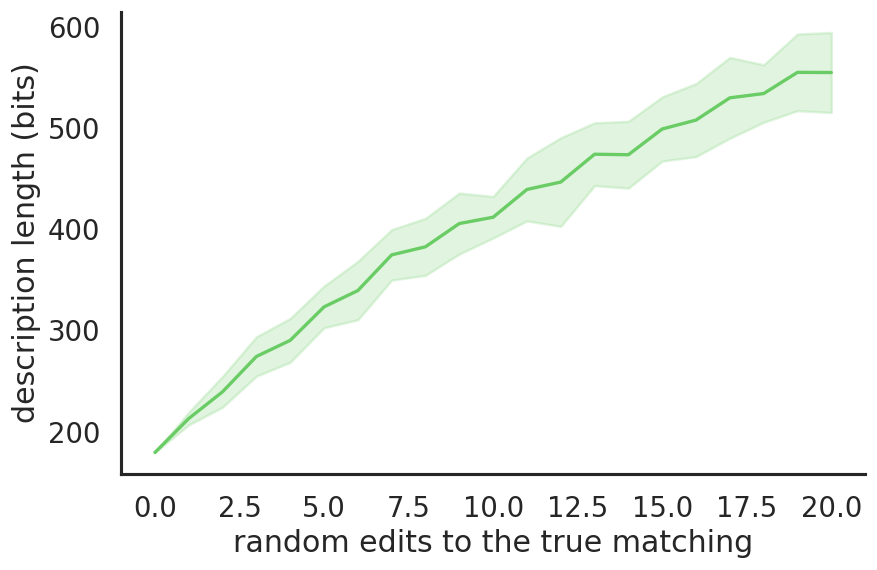

In [15]:
def assignment_cost(S, bgc_of_mol):
    # code length of one assignment under the fitted summary graph
    n = defaultdict(int)
    for j in range(N_m):
        i = int(bgc_of_mol[j])
        if i >= 0:
            n[(int(S.cb[i]), int(S.cm[j]))] += 1
    bits = 0.0
    for key in set(n) | set(S.hist):
        k = n.get(key, 0)
        h = S.hist.get(key)
        supp = int((h > 0).sum()) if h is not None else 1
        cnt = float(h[k]) if h is not None and k < len(h) else 0.0
        p = (cnt + SMOOTH) / (T + SMOOTH * max(supp + 1, 2))
        P, Q = key
        bits += -math.log2(p) + log2_binom(int(S.sb[P]), k) \
            + log2_binom(int(S.sm[Q]), k) + LOGF[k]
    return bits


truth_vec = np.full(N_m, -1, dtype=np.int32)
for i, j in true_pairs:
    truth_vec[j] = i


def edited(vec, n_edits, rng):
    v = vec.copy()
    for _ in range(n_edits):
        js = np.flatnonzero(v >= 0)
        j = int(rng.choice(js))
        i_new = int(rng.integers(0, N_b))
        v[v == i_new] = -1          # whoever held it loses it
        v[j] = i_new
    return v


rowsout = []
for n_ed in range(N_EDITS + 1):
    for s in range(N_EDIT_SEEDS):
        rng = np.random.default_rng(SEED + 1000 * n_ed + s)
        rowsout.append({"edits": n_ed, "seed": s,
                        "bits": assignment_cost(S, edited(truth_vec, n_ed, rng))})
edits = pd.DataFrame(rowsout)
agg = edits.groupby("edits")["bits"].agg(["mean", "std"]).reset_index()
slope = np.polyfit(agg["edits"], agg["mean"], 1)[0]
note("EDIT ROBUSTNESS", "bits at 0 edits", f"{agg['mean'].iloc[0]:.1f}")
note("EDIT ROBUSTNESS", f"bits at {N_EDITS} edits", f"{agg['mean'].iloc[-1]:.1f}")
note("EDIT ROBUSTNESS", "slope (bits per edit)", f"{slope:.2f}")
print(f"description length: {agg['mean'].iloc[0]:.1f} bits at 0 edits, "
      f"{agg['mean'].iloc[-1]:.1f} at {N_EDITS}, slope {slope:.2f} bits per edit")
if slope <= 0:
    print("WARNING: the curve does not increase, so the ground truth scores no "
          "better than a randomly edited version under this summary graph")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(agg["edits"], agg["mean"], color=COLORS["cupid"], lw=2)
ax.fill_between(agg["edits"], agg["mean"] - agg["std"], agg["mean"] + agg["std"],
                color=COLORS["cupid"], alpha=0.2)
ax.set_xlabel("random edits to the true matching")
ax.set_ylabel("description length (bits)")
ax.spines[["top", "right"]].set_visible(False)
save_fig(fig, "part6_edit_robustness", edits)
plt.show()

## 7. Ranking

Order every pair by support, the fraction of retained samples containing it. Support is heavily
tied, above all at zero, so ties are broken at random and the procedure repeated.

median rank of a true link: 39.5 of 7,488 (chance would give 3,744)


baseline median rank: 49.0


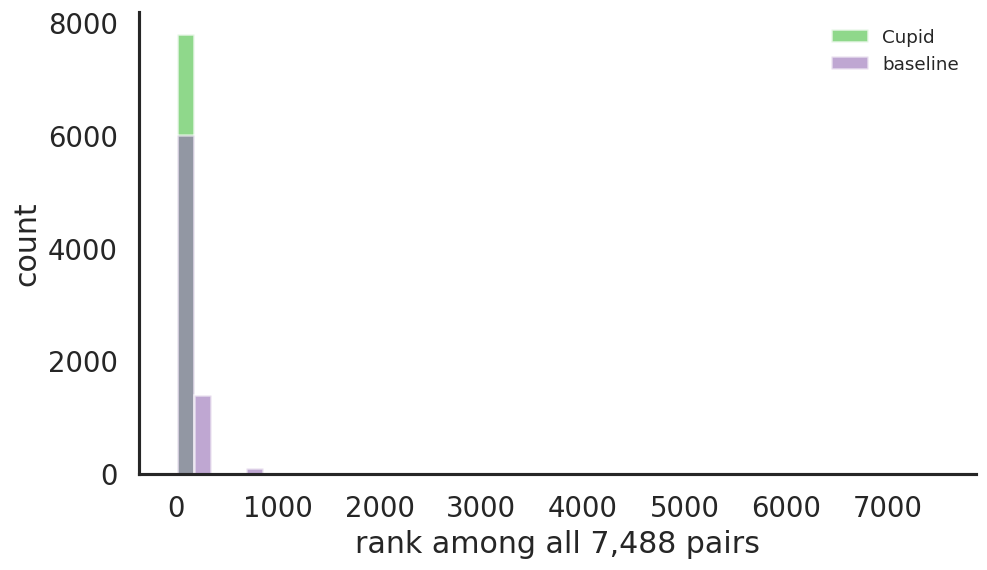

In [16]:
flat = support.ravel()
pair_b = np.repeat(np.arange(N_b), N_m)
pair_m = np.tile(np.arange(N_m), N_b)
is_true = np.zeros(N_b * N_m, dtype=bool)
for i, j in true_pairs:
    is_true[i * N_m + j] = True
true_idx = np.flatnonzero(is_true)

rank_rows = []
for r in range(N_TIE_RUNS):
    jitter = np.random.default_rng(SEED + r).permutation(len(flat))
    order_r = np.lexsort((jitter, -flat))
    rk = np.empty(len(flat), dtype=np.int32)
    rk[order_r] = np.arange(1, len(flat) + 1)
    for k in true_idx:
        rank_rows.append({"run": r, "pair": f"{bgcs[pair_b[k]]} -> {mols[pair_m[k]]}",
                          "rank": int(rk[k])})
ranks = pd.DataFrame(rank_rows)
per_run = ranks.groupby("run")["rank"].median()
med = per_run.mean()
note("RANKING", "median rank of a true link (Cupid)", f"{med:.1f}")
note("RANKING", "interquartile range", f"{ranks['rank'].quantile(0.25):.0f}-"
                                       f"{ranks['rank'].quantile(0.75):.0f}")
note("RANKING", "true links in the top 100",
     f"{(ranks.groupby('pair')['rank'].mean() <= 100).sum()} of {len(true_idx)}")
note("RANKING", "rank expected by chance", f"{len(flat) / 2:,.0f}")
print(f"median rank of a true link: {med:.1f} of {len(flat):,} "
      f"(chance would give {len(flat) / 2:,.0f})")

RANKS_CSV = OUT_DIR / "part7_ranks.csv"
ranks.to_csv(RANKS_CSV, index=False)
WRITTEN.append(RANKS_CSV)

fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(1, len(flat), 45)
ax.hist(ranks["rank"], bins=bins, color=COLORS["cupid"], alpha=0.75, label="Cupid")
base_med = None
if BASE_RANKS.exists():
    base = pd.read_csv(BASE_RANKS)
    ax.hist(base["rank"], bins=bins, color=COLORS["baseline"], alpha=0.6, label="baseline")
    base_med = base.groupby("run")["rank"].median().mean()
    note("RANKING", "median rank of a true link (baseline)", f"{base_med:.1f}")
    print(f"baseline median rank: {base_med:.1f}")
else:
    print("baseline ranks not found; run notebook 03 for the overlay")
ax.set_xlabel(f"rank among all {len(flat):,} pairs")
ax.set_ylabel("count")
ax.legend(fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
save_fig(fig, "part7_rank_distribution", ranks)
plt.show()

### Recall at k

The median rank above compresses the ranking into one number and hides its shape. Recall@k, the
fraction of the true links found after assaying the k best-scoring candidates, matches the decision
being supported, since k is an experimental budget.

Precision@k adds nothing, because the number of true links P is fixed and
`precision@k = recall@k * P / k`; it is kept in the CSV but not plotted. Accuracy is meaningless at
this prevalence, roughly 1%, and ROC-AUC is dominated by the thousands of true negatives. The
single-number summary is the average precision, the mean of the precision at the rank of each true
link, whose random-ranking value is P/N.

average precision: 0.987 (sd 0.0001 over 100 runs; random ranking gives 0.0104)

    k   hits   recall  precision  enrichment
   10   10.0     0.13       1.00         96x
   25   25.0     0.32       1.00         96x
   50   50.0     0.64       1.00         96x
  100   76.0     0.97       0.76         73x
  200   78.0     1.00       0.39         37x
  500   78.0     1.00       0.16         15x

baseline recall@100 0.76 against Cupid 0.97


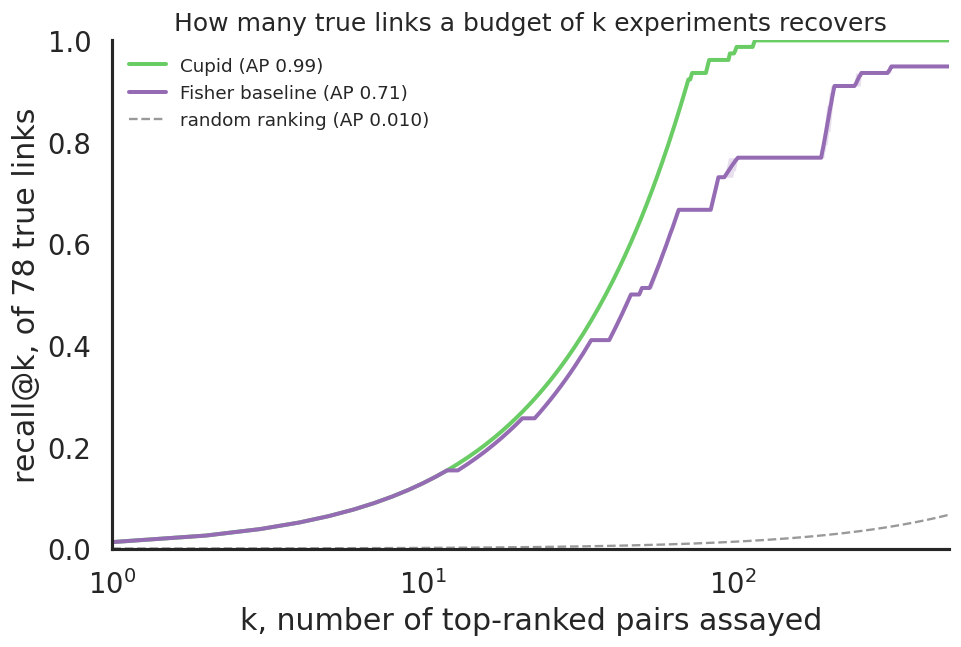

In [17]:
def recall_at_k(score, is_true, n_runs=N_TIE_RUNS, seed=SEED, descending=False):
    # Support is quantized by the number of retained samples and piles up at zero, and the
    # baseline's Fisher p-values are discrete, so in both cases a tie block straddling k would
    # make the curve depend on input order. Every run breaks ties uniformly at random and the
    # whole curve is recomputed, giving a mean and a min-max band.
    key = -np.asarray(score, dtype=float) if descending else np.asarray(score, dtype=float)
    N, P = len(key), int(is_true.sum())
    hits = np.empty((n_runs, N))
    aps = np.empty(n_runs)
    for r in range(n_runs):
        jitter = np.random.default_rng(seed + r).permutation(N)
        y = is_true[np.lexsort((jitter, key))]
        tp = np.cumsum(y)
        hits[r] = tp
        aps[r] = (tp / np.arange(1, N + 1))[y].mean()   # average precision
    k = np.arange(1, N + 1)
    curve = pd.DataFrame({
        "k": k,
        "hits_mean": hits.mean(0), "hits_lo": hits.min(0), "hits_hi": hits.max(0),
        "recall_mean": hits.mean(0) / P,
        "recall_lo": hits.min(0) / P, "recall_hi": hits.max(0) / P,
        "precision_mean": hits.mean(0) / k,
        "enrichment_mean": (hits.mean(0) / k) / (P / N),
        "recall_random": k / N,
    })
    return curve, aps


curve, aps = recall_at_k(flat, is_true, descending=True)
AP, AP_SD = aps.mean(), aps.std()
P_RATE = is_true.mean()
curve.to_csv(OUT_DIR / "part7_recall_at_k.csv", index=False)
WRITTEN.append(OUT_DIR / "part7_recall_at_k.csv")

note("RECALL AT K", "average precision (Cupid)", f"{AP:.3f}")
note("RECALL AT K", "average precision, sd over tie-break runs", f"{AP_SD:.4f}")
note("RECALL AT K", "average precision of a random ranking", f"{P_RATE:.4f}")
for k_ in (10, 25, 50, 100, 200, 500):
    note("RECALL AT K", f"recall@{k_} (Cupid)",
         f"{curve.iloc[k_ - 1].recall_mean:.2f} "
         f"({curve.iloc[k_ - 1].hits_mean:.0f} of {len(true_idx)})")
note("RECALL AT K", "enrichment at k=10 (Cupid)", f"{curve.iloc[9].enrichment_mean:.0f}x")

print(f"average precision: {AP:.3f} (sd {AP_SD:.4f} over {N_TIE_RUNS} runs; "
      f"random ranking gives {P_RATE:.4f})\n")
print(f"{'k':>5}{'hits':>7}{'recall':>9}{'precision':>11}{'enrichment':>12}")
for k_ in (10, 25, 50, 100, 200, 500):
    r_ = curve.iloc[k_ - 1]
    print(f"{k_:>5}{r_.hits_mean:>7.1f}{r_.recall_mean:>9.2f}"
          f"{r_.precision_mean:>11.2f}{r_.enrichment_mean:>11.0f}x")

fig, ax = plt.subplots(figsize=(9, 5.5))
sub = curve[curve["k"] <= K_PLOT_MAX]
ax.fill_between(sub["k"], sub["recall_lo"], sub["recall_hi"],
                color=COLORS["cupid"], alpha=0.22, lw=0)
ax.plot(sub["k"], sub["recall_mean"], color=COLORS["cupid"], lw=2.4,
        label=f"Cupid (AP {AP:.2f})")
if BASE_CURVE.exists():
    bcurve = pd.read_csv(BASE_CURVE)
    bsub = bcurve[bcurve["k"] <= K_PLOT_MAX]
    ax.fill_between(bsub["k"], bsub["recall_lo"], bsub["recall_hi"],
                    color=COLORS["baseline"], alpha=0.22, lw=0)
    # the baseline CSV stores the curve only, so its AP is recovered from the
    # per-run ranks that notebook 03 also writes
    base_ap = None
    if BASE_RANKS.exists():
        br = pd.read_csv(BASE_RANKS)
        base_ap = br.groupby("run")["rank"].apply(
            lambda s: (np.arange(1, len(s) + 1) / np.sort(s.to_numpy())).mean()).mean()
        note("RECALL AT K", "average precision (baseline)", f"{base_ap:.3f}")
    ax.plot(bsub["k"], bsub["recall_mean"], color=COLORS["baseline"], lw=2.4,
            label="Fisher baseline" + (f" (AP {base_ap:.2f})" if base_ap else ""))
    print(f"\nbaseline recall@100 {bsub.iloc[99].recall_mean:.2f} "
          f"against Cupid {sub.iloc[99].recall_mean:.2f}")
else:
    print("\nbaseline curve not found; run notebook 03 for the overlay")
ax.plot(sub["k"], sub["recall_random"], color="#999999", lw=1.4, ls="--",
        label=f"random ranking (AP {P_RATE:.3f})")
ax.set_xscale("log")
ax.set_xlim(1, K_PLOT_MAX)
ax.set_ylim(0, 1)
ax.set_xlabel("k, number of top-ranked pairs assayed")
ax.set_ylabel(f"recall@k, of {len(true_idx)} true links")
ax.set_title("How many true links a budget of k experiments recovers", fontsize=15)
ax.legend(fontsize=11, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
save_fig(fig, "part7_recall_at_k_comparison", sub)
plt.show()

## 8. A biological prior

Modular assembly lines add roughly one building block per module, so cluster length tracks product
size. This part tests whether encoding that as a prior helps, using the node features written by
notebook 01. The score becomes a rank correlation between BGC size and metabolite size over the
matched pairs, restricted to the modular classes, since terpenes and RiPPs do not follow the trend.

A rank correlation couples pairs, so the acceptance is no longer a table lookup and the mixing
guarantee of Part 2 does not apply here.

  gamma  0.0: median rank 39.5


  gamma 0.25: median rank 39.5


  gamma  0.5: median rank 39.5


  gamma  1.0: median rank 39.5


  gamma  2.0: median rank 39.5


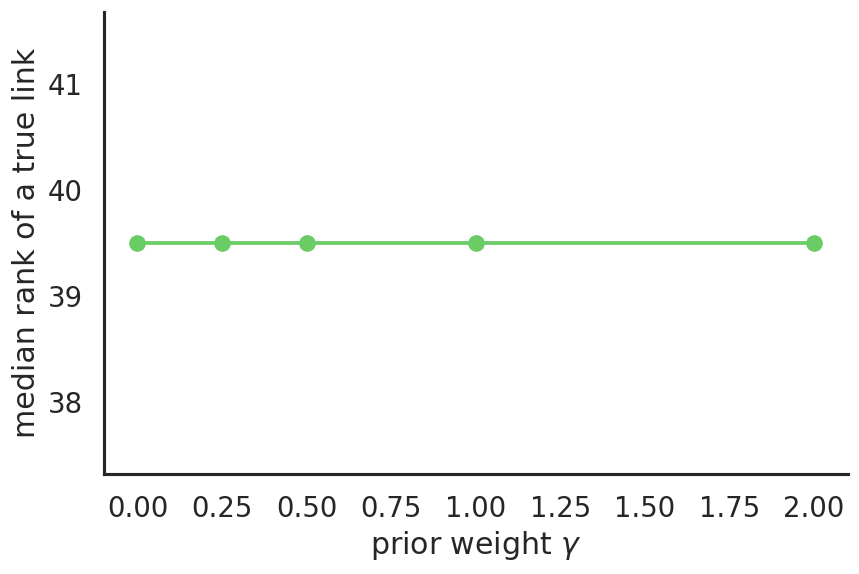

In [18]:
def prior_weight(gamma, feats):
    # a decomposable stand-in for the rank prior: reward pairs whose sizes sit at
    # similar quantiles of their own distribution, which keeps the chain O(1)
    bsz = np.array([feats["bgc"].get(b, np.nan) for b in bgcs], dtype=float)
    msz = np.array([feats["mol"].get(m, np.nan) for m in mols], dtype=float)
    ok_b, ok_m = ~np.isnan(bsz), ~np.isnan(msz)
    qb, qm = np.full(N_b, np.nan), np.full(N_m, np.nan)
    qb[ok_b] = pd.Series(bsz[ok_b]).rank(pct=True).to_numpy()
    qm[ok_m] = pd.Series(msz[ok_m]).rank(pct=True).to_numpy()
    d = np.abs(qb[:, None] - qm[None, :])
    d[np.isnan(d)] = 0.5                       # no feature, no opinion
    modular = np.array([str(feats["cls"].get(b, "")).lower() for b in bgcs])
    keep = np.array([("t1pks" in c) or ("nrps" in c) or ("hybrid" in c)
                     for c in modular])
    s = (0.5 - d)                              # positive when the sizes agree
    s[~keep, :] = 0.0
    return WEIGHT + gamma * s


feats, have_sizes = None, False
if FEATURES_CSV.exists():
    f = pd.read_csv(FEATURES_CSV)
    fam = f[f["ntype"] == "family"]
    mol = f[f["ntype"] == "molecule"]
    feats = {"bgc": dict(zip(fam["node"], fam["size"])),
             "mol": dict(zip(mol["node"], mol["size"])),
             "cls": dict(zip(fam["node"], fam["bgc_class"]))}
    have_sizes = mol["size"].notna().any()

if not have_sizes:
    print("metabolite sizes are empty in node_features.csv, so the prior cannot be "
          "evaluated; skipping (see notebook 01 for how the column is filled)")
    note("PRIOR", "evaluated", "no, metabolite sizes unavailable")
else:
    grid = [0.0, 0.25, 0.5, 1.0, 2.0]
    out = []
    for g in grid:
        smp, sc, _ = run_matching_chain(SEED, 2_000, weight=prior_weight(g, feats))
        keep_g = np.sort(np.argsort(-sc, kind="stable")[:500])
        sup_g = np.zeros((N_b, N_m))
        for t in keep_g:
            m = smp[t] >= 0
            sup_g[smp[t][m], rows[m]] += 1
        sup_g /= len(keep_g)
        fl = sup_g.ravel()
        rr = []
        for r in range(20):
            jit = np.random.default_rng(SEED + r).permutation(len(fl))
            o = np.lexsort((jit, -fl))
            rk = np.empty(len(fl), dtype=np.int32)
            rk[o] = np.arange(1, len(fl) + 1)
            rr.append(np.median(rk[true_idx]))
        out.append({"gamma": g, "median_rank": float(np.mean(rr))})
        print(f"  gamma {g:>4}: median rank {out[-1]['median_rank']:.1f}")
    sweep = pd.DataFrame(out)
    note("PRIOR", "best gamma", float(sweep.loc[sweep["median_rank"].idxmin(), "gamma"]))
    note("PRIOR", "median rank at best gamma", f"{sweep['median_rank'].min():.1f}")
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(sweep["gamma"], sweep["median_rank"], marker="o", color=COLORS["cupid"])
    ax.set_xlabel(r"prior weight $\gamma$")
    ax.set_ylabel("median rank of a true link")
    ax.spines[["top", "right"]].set_visible(False)
    save_fig(fig, "part8_prior_sweep", sweep)
    plt.show()

## 9. A second \textsc{Cupid} with the size prior

The idealized score in Part 0 has a third term, `GAMMA * s(A)`, which has been zero so far. Here it
is switched on with an explicit `GAMMA_PRIOR`, and `s(A)` is a genuine Kendall-type measure of how
badly an assignment violates the rule that larger clusters make larger molecules.

Take the matched pairs of `A` whose BGC is modular and whose two sizes are both known. Any two such
pairs are *discordant* when one has the larger cluster but the smaller molecule, that is when the
rule is broken. With `D(A)` discordant pairs out of `M(A)` comparisons,

`s(A) = -D(A) / M(A)`,

so `s` runs from `0` when the rule is never broken to `-1` when it always is, and it is exactly
`(tau - 1) / 2` for Kendall's tau over those pairs. A positive `GAMMA_PRIOR` therefore charges an
assignment in proportion to how wrong its size ordering is.

Unlike every term before it this one couples the matched pairs, so the acceptance is no longer a
table lookup and the mixing argument of Part 2 does not carry over. It stays cheap because a move
touches at most two pairs, so `D` and `M` are maintained incrementally and only the moved pair is
compared against the current set.

Part 8 scored its sweep by median rank, which is pinned at its floor here and cannot separate one
weight from another. The sweep below is rescored by average precision.

The prior can only speak about pairs whose BGC is modular and whose sizes are both known, 44% of
pairs and 35 of the 78 true links, so the two \textsc{Cupid} curves are expected to agree over much
of their range and a small effect is the expected outcome.

discordance: ground truth 0.331, retained draws without the prior 0.360


  gamma   0.0: AP 0.986


  gamma   1.0: AP 0.986


  gamma   2.0: AP 0.986


  gamma   5.0: AP 0.986


  gamma  10.0: AP 0.984


  gamma  20.0: AP 0.984



gamma 3.0: discordance 0.360 -> 0.358, AP 0.987 -> 0.987 (+0.000)


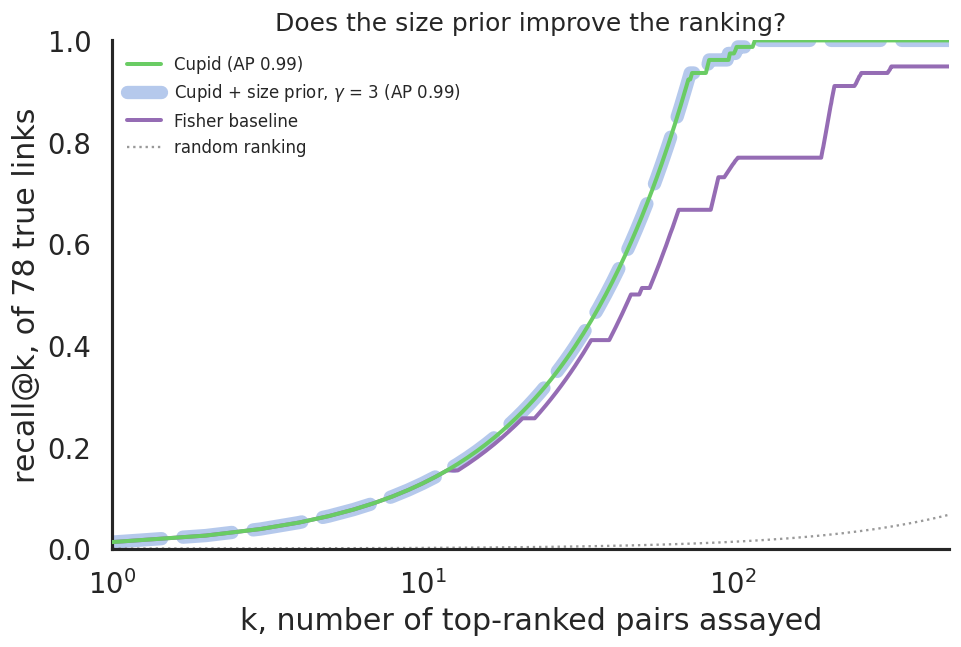

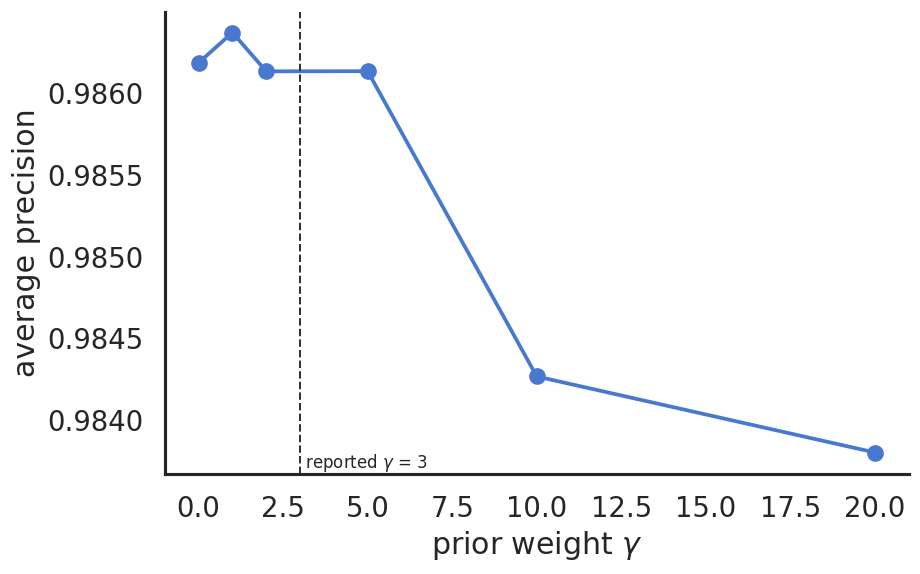

In [19]:
if not have_sizes:
    print("metabolite sizes unavailable, so the prior variant is skipped")
    note("SIZE PRIOR", "evaluated", "no, metabolite sizes unavailable")
else:
    # per-node quantiles; NaN marks a node the prior has no opinion about, either
    # because the BGC is not a modular assembly line or because a size is missing
    _f = pd.read_csv(FEATURES_CSV)
    _fam, _mol = _f[_f["ntype"] == "family"], _f[_f["ntype"] == "molecule"]
    _bs, _ms = dict(zip(_fam["node"], _fam["size"])), dict(zip(_mol["node"], _mol["size"]))
    _cl = dict(zip(_fam["node"], _fam["bgc_class"]))
    bsz = np.array([_bs.get(b, np.nan) for b in bgcs], dtype=float)
    msz = np.array([_ms.get(m, np.nan) for m in mols], dtype=float)
    modular = np.array([any(k in str(_cl.get(b, "")).lower()
                            for k in ("t1pks", "nrps", "hybrid")) for b in bgcs])
    QB = np.where(modular & ~np.isnan(bsz), pd.Series(bsz).rank(pct=True).to_numpy(), np.nan)
    QM = np.where(~np.isnan(msz), pd.Series(msz).rank(pct=True).to_numpy(), np.nan)
    note("SIZE PRIOR", "BGCs the prior can speak about", f"{int(np.sum(~np.isnan(QB)))} of {N_b}")
    note("SIZE PRIOR", "metabolites the prior can speak about",
         f"{int(np.sum(~np.isnan(QM)))} of {N_m}")


    def discordance(bgc_of_mol):
        # D and M for a whole assignment, used for reporting rather than in the chain
        q_b = np.array([QB[int(i)] if i >= 0 else np.nan for i in bgc_of_mol])
        ok = ~np.isnan(q_b) & ~np.isnan(QM)
        x, y = q_b[ok], QM[ok]
        D = int(((x[:, None] - x[None, :]) * (y[:, None] - y[None, :]) < 0).sum() // 2)
        M = len(x) * (len(x) - 1) // 2
        return D, M


    def run_prior_chain(seed, n_samples, gamma, weight=None,
                        burn_in=BURN_IN, thin=THIN):
        weight = WEIGHT if weight is None else weight
        rng = np.random.default_rng(seed)
        mol_of = np.full(N_b, -1, dtype=np.int32)
        bgc_of = np.full(N_m, -1, dtype=np.int32)
        qb_at = np.full(N_m, np.nan)      # quantile of the BGC matched to each metabolite
        D = M = 0                         # discordant comparisons, and comparisons made
        total = burn_in + n_samples * thin
        ii = rng.integers(0, N_b, size=total)
        jj = rng.integers(0, N_m, size=total)
        uu = np.log(rng.random(total))
        out = np.empty((n_samples, N_m), dtype=np.int32)
        scores_ = np.empty(n_samples)

        def clash(qbv, qmv, excl):
            # how many currently comparable matched pairs break the rule against this one
            m_ = ~np.isnan(qb_at)
            if excl >= 0:
                m_[excl] = False
            return int(((qbv - qb_at[m_]) * (qmv - QM[m_]) < 0).sum()), int(m_.sum())

        def s_of(D_, M_):
            return -D_ / M_ if M_ > 0 else 0.0

        score, accepted, k = 0.0, 0, 0
        for step in range(total):
            i, j = int(ii[step]), int(jj[step])
            cur_j, cur_i = int(mol_of[i]), int(bgc_of[j])
            new_comp = not (np.isnan(QB[i]) or np.isnan(QM[j]))
            evicted, dD, dM = -1, 0, 0
            if cur_j == j:                                   # remove the pair
                delta, kind = -weight[i, j], 0
                if new_comp:
                    c, n = clash(QB[i], QM[j], j)
                    dD, dM = -c, -n
            elif cur_j == -1 and cur_i == -1:                # add it
                delta, kind = weight[i, j], 1
                if new_comp:
                    c, n = clash(QB[i], QM[j], -1)
                    dD, dM = c, n
            elif cur_j != -1 and cur_i == -1:                # re-aim a busy BGC
                delta, kind, evicted = weight[i, j] - weight[i, cur_j], 2, cur_j
                if not np.isnan(qb_at[cur_j]):
                    c, n = clash(qb_at[cur_j], QM[cur_j], cur_j)
                    dD, dM = dD - c, dM - n
                if new_comp:
                    c, n = clash(QB[i], QM[j], cur_j)
                    dD, dM = dD + c, dM + n
            elif cur_j == -1 and cur_i != -1:                # steal a taken metabolite
                delta, kind, evicted = weight[i, j] - weight[cur_i, j], 3, cur_i
                if not np.isnan(qb_at[j]):
                    c, n = clash(qb_at[j], QM[j], j)
                    dD, dM = dD - c, dM - n
                if new_comp:
                    c, n = clash(QB[i], QM[j], j)
                    dD, dM = dD + c, dM + n
            else:                                            # both busy elsewhere
                kind = -1
            if kind >= 0:
                delta = delta + gamma * (s_of(D + dD, M + dM) - s_of(D, M))
                if delta >= 0 or uu[step] < delta:
                    accepted += 1
                    if kind == 0:
                        mol_of[i] = -1
                        bgc_of[j] = -1
                        qb_at[j] = np.nan
                    else:
                        if kind == 2:
                            bgc_of[evicted] = -1
                            qb_at[evicted] = np.nan
                        elif kind == 3:
                            mol_of[evicted] = -1
                        mol_of[i] = j
                        bgc_of[j] = i
                        qb_at[j] = QB[i] if new_comp else np.nan
                    D, M = D + dD, M + dM
                    score += delta
            if step >= burn_in and (step - burn_in) % thin == 0 and k < n_samples:
                out[k] = bgc_of
                scores_[k] = score
                k += 1
        return out, scores_, accepted / total


    def support_of(smp):
        # no filter, matching Part 3: the marginal is taken over every draw
        s_ = np.zeros((N_b, N_m))
        for t in range(len(smp)):
            mm = smp[t] >= 0
            s_[smp[t][mm], rows[mm]] += 1
        return s_ / len(smp)


    # how wrong is the ground truth itself, and how wrong are the unbiased draws?
    D_t, M_t = discordance(truth_vec)
    d_kept = np.mean([discordance(kept[t])[0] / max(discordance(kept[t])[1], 1)
                      for t in range(0, T, 20)])
    note("SIZE PRIOR", "discordance of the ground truth",
         f"{D_t / max(M_t, 1):.3f} ({D_t} of {M_t})")
    note("SIZE PRIOR", "mean discordance, retained draws without the prior", f"{d_kept:.3f}")
    print(f"discordance: ground truth {D_t / max(M_t, 1):.3f}, "
          f"retained draws without the prior {d_kept:.3f}")

    # sweep, scored by average precision rather than median rank
    sweep_rows = []
    for g in (0.0, 1.0, 2.0, 5.0, 10.0, 20.0):
        smp_, sc_, _ = run_prior_chain(SEED, 5_000, g)
        _, aps_ = recall_at_k(support_of(smp_).ravel(), is_true,
                              n_runs=10, descending=True)
        sweep_rows.append({"gamma": g, "average_precision": float(aps_.mean())})
        print(f"  gamma {g:>5}: AP {aps_.mean():.3f}")
    ap_sweep = pd.DataFrame(sweep_rows)
    note("SIZE PRIOR", "gamma grid searched",
         ", ".join(str(g) for g in ap_sweep["gamma"]))
    note("SIZE PRIOR", "best gamma on the grid",
         float(ap_sweep.loc[ap_sweep["average_precision"].idxmax(), "gamma"]))

    # the reported variant, at the weight fixed in Part 0
    smp_p, sc_p, acc_p = run_prior_chain(SEED, N_SAMPLES, GAMMA_PRIOR)
    sup_p = support_of(smp_p)
    kept_p = smp_p
    d_prior = np.mean([discordance(kept_p[t])[0] / max(discordance(kept_p[t])[1], 1)
                       for t in range(0, len(kept_p), 20)])
    curve_prior, aps_prior = recall_at_k(sup_p.ravel(), is_true, descending=True)
    AP_PRIOR = float(aps_prior.mean())
    note("SIZE PRIOR", "gamma used for the reported variant", GAMMA_PRIOR)
    note("SIZE PRIOR", "acceptance rate", f"{acc_p:.1%}")
    note("SIZE PRIOR", "mean discordance, retained draws with the prior", f"{d_prior:.3f}")
    note("SIZE PRIOR", "average precision (Cupid + size prior)", f"{AP_PRIOR:.3f}")
    note("SIZE PRIOR", "average precision (Cupid, no prior)", f"{AP:.3f}")
    note("SIZE PRIOR", "change in average precision", f"{AP_PRIOR - AP:+.3f}")
    for k_ in (25, 50, 100, 200):
        note("SIZE PRIOR", f"recall@{k_} (Cupid + size prior)",
             f"{curve_prior.iloc[k_ - 1].recall_mean:.2f} "
             f"({curve_prior.iloc[k_ - 1].hits_mean:.0f} of {len(true_idx)})")
    print(f"\ngamma {GAMMA_PRIOR}: discordance {d_kept:.3f} -> {d_prior:.3f}, "
          f"AP {AP:.3f} -> {AP_PRIOR:.3f} ({AP_PRIOR - AP:+.3f})")

    fig, ax = plt.subplots(figsize=(9, 5.5))
    sub_c = curve[curve["k"] <= K_PLOT_MAX]
    sub_p = curve_prior[curve_prior["k"] <= K_PLOT_MAX]
    # The prior variant sits underneath as a thick translucent band rather than beside
    # the unbiased curve. The two coincide over most of the range, and a band lets the
    # thin curve stay readable on top of it while still showing where they part.
    ln_p, = ax.plot(sub_p["k"], sub_p["recall_mean"], color=COLORS["prior"], lw=8.0,
                    alpha=0.40, ls="--", dash_capstyle="round", zorder=1,
                    label=f"Cupid + size prior, $\\gamma$ = {GAMMA_PRIOR:g} "
                          f"(AP {AP_PRIOR:.2f})")
    ln_c, = ax.plot(sub_c["k"], sub_c["recall_mean"], color=COLORS["cupid"], lw=2.4,
                    zorder=4, label=f"Cupid (AP {AP:.2f})")
    frames = [sub_c.assign(method="cupid"), sub_p.assign(method="cupid_size_prior")]
    handles = [ln_c, ln_p]
    if BASE_CURVE.exists():
        bsub = pd.read_csv(BASE_CURVE)
        bsub = bsub[bsub["k"] <= K_PLOT_MAX]
        ln_b, = ax.plot(bsub["k"], bsub["recall_mean"], color=COLORS["baseline"], lw=2.4,
                        zorder=3, label="Fisher baseline")
        frames.append(bsub.assign(method="baseline"))
        handles.append(ln_b)
    ln_r, = ax.plot(sub_c["k"], sub_c["recall_random"], color="#999999", lw=1.4, ls=":",
                    zorder=2, label="random ranking")
    handles.append(ln_r)
    ax.set_xscale("log")
    ax.set_xlim(1, K_PLOT_MAX)
    ax.set_ylim(0, 1)
    ax.set_xlabel("k, number of top-ranked pairs assayed")
    ax.set_ylabel(f"recall@k, of {len(true_idx)} true links")
    ax.set_title("Does the size prior improve the ranking?", fontsize=15)
    ax.legend(handles=handles, fontsize=10, loc="upper left")
    ax.spines[["top", "right"]].set_visible(False)
    save_fig(fig, "part9_recall_at_k_prior", pd.concat(frames, ignore_index=True))
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(ap_sweep["gamma"], ap_sweep["average_precision"], marker="o",
            color=COLORS["prior"])
    ax.axvline(GAMMA_PRIOR, color="#333333", ls="--", lw=1.2)
    ax.text(GAMMA_PRIOR, ax.get_ylim()[0], f" reported $\\gamma$ = {GAMMA_PRIOR:g}",
            fontsize=10, va="bottom")
    ax.set_xlabel(r"prior weight $\gamma$")
    ax.set_ylabel("average precision")
    ax.spines[["top", "right"]].set_visible(False)
    save_fig(fig, "part9_prior_sweep_ap", ap_sweep)
    plt.show()

## 10. Summary

In [20]:
SUMMARY_TXT = OUT_DIR / "summary.txt"
lines, last = [], None
for section, key, value in FACTS:
    if section != last:
        lines.append("" if last else None)
        lines.append(section)
        last = section
    lines.append(f"{key:<48}{value}")
text = ("notebook 02 - cupid summary\n" + "=" * 62 + "\n"
        + "\n".join(l for l in lines if l is not None) + "\n")
SUMMARY_TXT.write_text(text)
WRITTEN.append(SUMMARY_TXT)
print(text)

notebook 02 - cupid summary
SETUP
strains (N_s)                                   62
BGCs (N_b)                                      96
metabolites (N_m)                               78
true links                                      78

CONFIGURATION
alpha                                           20.0
beta                                            10.0
gamma                                           0.0
seed                                            0
mu                                              1.0
samples drawn                                   1000
samples kept                                    all, no filter
burn-in                                         500000
thinning                                        200
clustering steps                                10000

SETUP
conflict-free pairs                             725
maximum conflict-free matching size (exact)     78

SAMPLER
acceptance rate                                 0.7%
assignments used, no filter           

## 11. Ablation over the three weights

Every result above uses $\alpha = 20$, $\beta = 10$, $\mu = 1$, fixed a priori. This part rebuilds
the ranking for a grid of alternatives to show how much those choices matter.

We take each weight from $\{1, 5, 10, 20\}$ and keep the settings with
$\alpha \geq \beta \geq \mu$, which is 20 of the 64 combinations. The ordering is not arbitrary.
$\mu$ is charged per carrier that never produces, and the median conflict-free pair has eight of
them, so a $\mu$ above $\alpha$ makes almost every pair too expensive to match and the assignments
collapse to nearly empty. Those cells would tell us only that the score can be broken.

Everything else is held fixed, including $\gamma = 0$, the chain length and the seed, so the only
thing that changes between rows is the weight vector.

In [21]:
N_PAIRS_TOTAL = N_b * N_m
ABL_VALUES = (1, 5, 10, 20)
ABL = [(a, b, m) for a in ABL_VALUES for b in ABL_VALUES for m in ABL_VALUES
       if a > b > m]
print(f"{len(ABL)} settings with alpha > beta > mu, "
      f"{len(ABL_VALUES) ** 3 - len(ABL)} skipped")

abl_rows, abl_curves = [], []
t0 = time.time()
for n_done, (a_, b_, m_) in enumerate(ABL, 1):
    smp, _, acc_ = run_matching_chain(SEED, N_SAMPLES, weight=a_ - b_ * C - m_ * N10)
    sz_ = (smp >= 0).sum(1)
    cf_ = np.array([C[smp[t][smp[t] >= 0], rows[smp[t] >= 0]].sum() for t in range(len(smp))])
    sup_ = np.zeros((N_b, N_m))
    for t in range(len(smp)):
        mm_ = smp[t] >= 0
        sup_[smp[t][mm_], rows[mm_]] += 1
    sup_ /= len(smp)
    curve_, aps_ = recall_at_k(sup_.ravel(), is_true, descending=True)
    covered = sum(1 for i, j in true_pairs if sup_[i, j] > 0)
    abl_rows.append({
        "alpha": a_, "beta": b_, "mu": m_,
        "average_precision": float(aps_.mean()),
        "recall_at_25": curve_.recall_mean.iat[24],
        "recall_at_50": curve_.recall_mean.iat[49],
        "recall_at_100": curve_.recall_mean.iat[99],
        "recall_at_200": curve_.recall_mean.iat[199],
        "hits_at_100": curve_.hits_mean.iat[99],
        "share_optimal": float(((cf_ == 0) & (sz_ == MAX_SIZE)).mean()),
        "share_conflict_free": float((cf_ == 0).mean()),
        "size_mean": float(sz_.mean()), "size_min": int(sz_.min()), "size_max": int(sz_.max()),
        "true_links_covered": covered, "acceptance": acc_,
        "is_default": (a_, b_, m_) == (ALPHA, BETA, MU)})
    abl_curves.append(curve_[curve_["k"] <= K_PLOT_MAX]
                      .assign(alpha=a_, beta=b_, mu=m_))
    print(f"  {n_done:>2}/{len(ABL)}  alpha {a_:>2} beta {b_:>2} mu {m_:>2}  "
          f"AP {aps_.mean():.3f}  optimal {((cf_ == 0) & (sz_ == MAX_SIZE)).mean():5.1%}  "
          f"|A| {sz_.mean():5.1f}   [{time.time() - t0:.0f}s]")

abl = pd.DataFrame(abl_rows).sort_values("average_precision", ascending=False)
ABL_CSV = OUT_DIR / "part11_ablation_summary.csv"
abl.to_csv(ABL_CSV, index=False)
WRITTEN.append(ABL_CSV)
print(f"\naverage precision over the {len(ABL)} settings: "
      f"{abl.average_precision.min():.3f} to {abl.average_precision.max():.3f}")
print(abl[["alpha", "beta", "mu", "average_precision", "hits_at_100",
           "share_optimal", "size_mean"]].to_string(index=False))

4 settings with alpha > beta > mu, 60 skipped


   1/4  alpha 10 beta  5 mu  1  AP 0.972  optimal  0.0%  |A|  75.1   [0s]


   2/4  alpha 20 beta  5 mu  1  AP 0.985  optimal 31.9%  |A|  77.9   [1s]


   3/4  alpha 20 beta 10 mu  1  AP 0.987  optimal 88.9%  |A|  77.9   [1s]


   4/4  alpha 20 beta 10 mu  5  AP 0.831  optimal  0.0%  |A|  63.9   [2s]

average precision over the 4 settings: 0.831 to 0.987
 alpha  beta  mu  average_precision  hits_at_100  share_optimal  size_mean
    20    10   1           0.986679         76.0          0.889     77.889
    20     5   1           0.985258         75.0          0.319     77.889
    10     5   1           0.972398         74.0          0.000     75.105
    20    10   5           0.831034         66.0          0.000     63.863


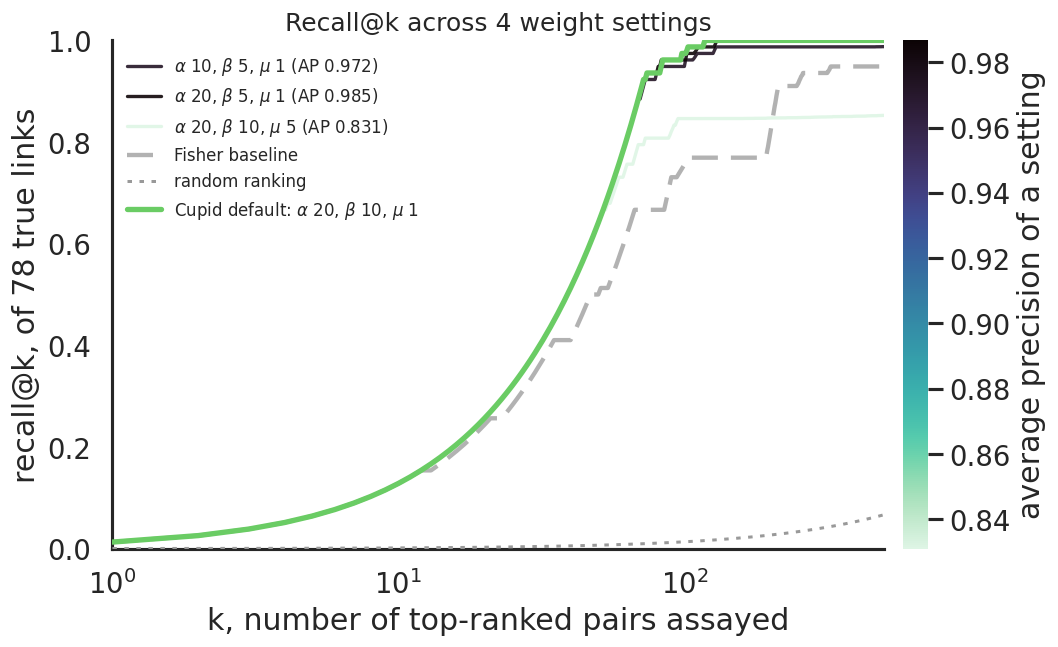

In [22]:
# Every setting is drawn, but many coincide exactly: at k = 25 the 20 curves take only a
# couple of distinct values. They are therefore drawn semi-transparent, so overlapping
# curves read as a darker line rather than hiding one another.
fig, ax = plt.subplots(figsize=(10, 5.5))
cmap = sns.color_palette("mako_r", as_cmap=True)
lo, hi = abl.average_precision.min(), abl.average_precision.max()
for row, curve_ in zip(abl_rows, abl_curves):
    if row["is_default"]:
        continue
    ax.plot(curve_["k"], curve_["recall_mean"], lw=2.0, alpha=0.9,
            color=cmap((row["average_precision"] - lo) / max(hi - lo, 1e-9)), zorder=2,
            label=f"$\\alpha$ {row['alpha']:g}, $\\beta$ {row['beta']:g}, "
                  f"$\\mu$ {row['mu']:g} (AP {row['average_precision']:.3f})")

frames = list(abl_curves)
if BASE_CURVE.exists():
    bsub = pd.read_csv(BASE_CURVE)
    bsub = bsub[bsub["k"] <= K_PLOT_MAX]
    ax.plot(bsub["k"], bsub["recall_mean"], lw=2.6, color="#666666", alpha=0.5,
            ls=(0, (6, 3)), zorder=3, label="Fisher baseline")
    frames.append(bsub.assign(alpha=np.nan, beta=np.nan, mu=np.nan, method="baseline"))
kk = np.arange(1, K_PLOT_MAX + 1)
ax.plot(kk, kk / N_PAIRS_TOTAL, lw=1.8, ls=(0, (1.5, 2.5)), color="#999999", zorder=3,
        label="random ranking")
frames.append(pd.DataFrame({"k": kk, "recall_mean": kk / N_PAIRS_TOTAL,
                            "alpha": np.nan, "beta": np.nan, "mu": np.nan,
                            "method": "random"}))

dflt = [c for r, c in zip(abl_rows, abl_curves) if r["is_default"]][0]
ax.plot(dflt["k"], dflt["recall_mean"], lw=3.2, color=COLORS["cupid"], zorder=5,
        label=f"Cupid default: $\\alpha$ {ALPHA:g}, $\\beta$ {BETA:g}, $\\mu$ {MU:g}")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=lo, vmax=hi))
cb = fig.colorbar(sm, ax=ax, pad=0.02)
cb.set_label("average precision of a setting")
cb.outline.set_visible(False)
ax.set_xscale("log")
ax.set_xlim(1, K_PLOT_MAX)
ax.set_ylim(0, 1)
ax.set_xlabel("k, number of top-ranked pairs assayed")
ax.set_ylabel(f"recall@k, of {len(true_idx)} true links")
ax.set_title(f"Recall@k across {len(ABL)} weight settings", fontsize=15)
ax.legend(fontsize=10, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
save_fig(fig, "part11_ablation_recall_at_k", pd.concat(frames, ignore_index=True))
plt.show()

In [23]:
print(f"{len(WRITTEN)} files written:")
for p_ in WRITTEN:
    print(f"  {p_.relative_to(REPO_ROOT)}")

43 files written:
  output/02_streptomyces_cupid/part3_sample_distributions.jpg
  output/02_streptomyces_cupid/part3_sample_distributions.pdf
  output/02_streptomyces_cupid/part3_sample_distributions.csv
  output/02_streptomyces_cupid/part3_joint_distribution.jpg
  output/02_streptomyces_cupid/part3_joint_distribution.pdf
  output/02_streptomyces_cupid/part3_joint_distribution.csv
  output/02_streptomyces_cupid/part4_assignment_graph.jpg
  output/02_streptomyces_cupid/part4_assignment_graph.pdf
  output/02_streptomyces_cupid/part4_assignment_graph.csv
  output/02_streptomyces_cupid/part4_assignment_graph_subset.jpg
  output/02_streptomyces_cupid/part4_assignment_graph_subset.pdf
  output/02_streptomyces_cupid/part4_assignment_graph_subset.csv
  output/02_streptomyces_cupid/part5_summary_graph.jpg
  output/02_streptomyces_cupid/part5_summary_graph.pdf
  output/02_streptomyces_cupid/part5_summary_graph.csv
  output/02_streptomyces_cupid/part5_summary_graph_layered.jpg
  output/02_strepto